In [75]:
from typing import Literal

from common import AudioEncoderType

DATASET_NAMES: list[str] = ["zoo", "trick", "lobster"]

# we can test on specific dataset entirely
TEST_DATASET_NAME: str | None = None  # set to literal "subset" to use subset of dataset or set to another dataset name

# OR on fraction of all datasets
TEST_DATASET_FRACTION: float = 0.15  # set to determine which % of test datasets rows will be reserved for testing

# OR run KFold on all datasets
MULTIFOLD_TEST: bool = False  # whether we use kfold split or not
MULTIFOLD_ORDINAL: int = 5  # ordinal number of fold to run. Fold count is defined as 1/TEST_DATASET_FRACTION.

TARGET_COLUMN: Literal["label1", "speed"] = "label1"  # what to predict

# for target=label1
THRESHOLD_SPLITS = 3  # 2 or 3 - number of classes to split dataset to
SMOOTHING = True  # bool; True => 0.345, 0.768. False => 0, 0.5
SCALE_TYPE: Literal["lower_is_better", "higher_is_better"] = "lower_is_better"
SMOOTHING_CLAMP_TYPE: Literal["max", "softmax"] = "max"
CALCULATE_THRESHOLDS = False  # bool; False = use precomputed thresholds per class+text; True - calculate meanstd thresholds inplace. Doesn't work with smoothing=0
BALANCE_DATASET = True  # bool; True to align with minority, False to leave it as it is

NORMALIZE_GRADE = True  # make grades from 1,2,3,4 to 0.25,0.5,0.75,1.0

REDUCE_DIMS = True  # todo: make it reduce_dims: int|None

# do not forget to use names instead of enums for multirun compat
AUDIO_ENCODER_TYPE: str = AudioEncoderType.whisper60s_mean.name

PLOT_CLUSTERING = False
PLOT_STRAT_CLUSTERING = False
PLOT_SMOOTHING = True

In [ ]:
# from common import Config, ValueSpec
#
#
# CONFIG = Config([
#     ValueSpec("DATASET_NAMES", ["zoo", "trick", "lobster"], None).value,
# ])
# USE_ZOO
# USE_TRICK
# USE_LOBSTER


In [ ]:
import os

In [ ]:
DATASET_NAMES = list(sorted(DATASET_NAMES))

In [83]:
from multirun import make_title

RUN_NUMBER = 0
REPORT_FOLDER = os.path.join("output")
os.makedirs(REPORT_FOLDER, exist_ok=True)

additional_kw = {
    "MULTIFOLD_TEST": MULTIFOLD_TEST,
    "MULTIFOLD_ORDINAL": MULTIFOLD_ORDINAL,
    "SMOOTHING": SMOOTHING,
    "SCALE_TYPE": SCALE_TYPE,
    "SMOOTHING_CLAMP_TYPE": SMOOTHING_CLAMP_TYPE,
    "CALCULATE_THRESHOLDS": CALCULATE_THRESHOLDS
}

while True:
    RUN_TITLE = make_title(DATASET_NAMES, TEST_DATASET_NAME, AUDIO_ENCODER_TYPE, THRESHOLD_SPLITS, BALANCE_DATASET,
                           RUN_NUMBER, **additional_kw)

    REPORT_FOLDER = os.path.join("output", RUN_TITLE)
    if os.path.exists(REPORT_FOLDER):
        RUN_NUMBER += 1
        continue
    print(RUN_TITLE)
    os.makedirs(REPORT_FOLDER, exist_ok=True)
    break

lobster+trick+zoo_on-subset_enc-whisper60s_mean_splits-3_balance-1__0MULTIFOLD_TEST=False_MULTIFOLD_ORDINAL=5_SMOOTHING=True_SCALE_TYPE=lower_is_better_SMOOTHING_CLAMP_TYPE=max_CALCULATE_THRESHOLDS=False


In [84]:
import pandas as pd
import numpy as np
from tqdm import tqdm

In [85]:
import plotly.graph_objects as go
import matplotlib.pyplot as plt

In [86]:
from enum import Enum


class ReportTarget(Enum):
    header = 0
    body = 1
    footer = 2


class Report:
    def __init__(self, output_dir: str):
        self.output_dir = output_dir
        self.img_count = 0
        self.storage = dict()

        self.markdown = {
            ReportTarget.header: [f"# {RUN_TITLE}\n"],
            ReportTarget.body: [],
            ReportTarget.footer: []
        }

        self.storage["name"] = RUN_TITLE
        self.img_rel_folder_path = os.path.join("img")
        self.img_root_folder_path = os.path.join(self.output_dir, "img")
        os.makedirs(self.img_root_folder_path, exist_ok=True)
        self.md_path = os.path.join(self.output_dir, RUN_TITLE + ".md")
        self.pdf_path = os.path.join(self.output_dir, RUN_TITLE + ".pdf")
        self.csv_path = os.path.join(self.output_dir, "report.csv")
        self("DATASET_NAMES", DATASET_NAMES, target=ReportTarget.header)
        self("TEST_DATASET_NAME", TEST_DATASET_NAME if TEST_DATASET_NAME else "subset", target=ReportTarget.header)
        self("THRESHOLD_SPLITS", THRESHOLD_SPLITS, target=ReportTarget.header)
        self("AUDIO_ENCODER_TYPE", AUDIO_ENCODER_TYPE, target=ReportTarget.header)
        self("BALANCE_DATASET", BALANCE_DATASET, target=ReportTarget.header)

        if os.path.exists(self.pdf_path):
            raise Exception(f"{RUN_TITLE} already exists, skipping.#exists")

    def __call__(self, key: str, value, target: ReportTarget = ReportTarget.body):
        print(f"{key}: {value}")
        self.storage[key] = value
        self.markdown[target].append(f"{key}: {value}")
        self.storage[key] = value

    def add_image(self, img_name: str = "", target: ReportTarget = ReportTarget.body):
        img_name = img_name.replace(" ", "_")
        img_name = f"{self.img_count:02}_{img_name}.png"
        img_abs_path = os.path.join(self.img_root_folder_path, img_name)

        img_rel_path = os.path.join(self.img_rel_folder_path, img_name)
        self.markdown[target].append(f"![{img_name}]({img_rel_path})\n\nImage above is _{img_name}_\n\n")

        self.img_count += 1
        return img_abs_path

    def section(self, section_name: str = "", target: ReportTarget = ReportTarget.body):
        self.markdown[target].append(f"--- \n\n ")
        section_text = f" \n\n"
        if section_name:
            section_text = f"## {section_name}\n\n"
        print(section_text)
        self.markdown[target].append(section_text)

    def save(self):

        store = {k: [v] for k, v in self.storage.items()}
        report_df = pd.DataFrame(store)
        report_df.to_csv(self.csv_path, index=False)

        markdowns = [
            "\n\n".join(self.markdown[target]) for target in
            [ReportTarget.header, ReportTarget.body, ReportTarget.footer]
        ]
        markdown_content = "\n\n".join(markdowns)
        with open(self.md_path, "w") as f:
            f.write(markdown_content)
        from markdown_pdf import MarkdownPdf, Section
        pdf = MarkdownPdf()
        pdf.add_section(Section(markdown_content, root=self.output_dir))
        pdf.save(self.pdf_path)
        # md_to_pdf(self.md_path, self.pdf_path)
        print("pdf saved")




In [87]:
report = Report(REPORT_FOLDER)


DATASET_NAMES: ['lobster', 'trick', 'zoo']
TEST_DATASET_NAME: subset
THRESHOLD_SPLITS: 3
AUDIO_ENCODER_TYPE: whisper60s_mean
BALANCE_DATASET: True


In [88]:
import builtins

try:
    if builtins.regr_monkey_patched:
        print("Monkey patched already, skipping.")
except:
    _orig_show = go.Figure.show


    def plotly_show_and_save(self, filename: str, *args, **kwargs):
        """Monkey-patched show: saves figure automatically if filename is given."""
        full_path = report.add_image(filename)
        self.write_image(full_path, width=800, height=600, scale=2)
        return _orig_show(self, *args, **kwargs)


    go.Figure.show = plotly_show_and_save

    _orig_plt_show = plt.show


    def plotly_show_and_save(filename: str, *args, **kwargs):
        for i, fig_num in enumerate(plt.get_fignums(), 1):
            fig = plt.figure(fig_num)
            full_path = report.add_image(filename)
            fig.savefig(full_path, bbox_inches='tight', dpi=150)
        return _orig_plt_show(*args, **kwargs)


    plt.show = plotly_show_and_save
    builtins.regr_monkey_patched = True


Monkey patched already, skipping.


In [89]:
import os

ffmpeg_path = os.path.join(os.getcwd(), "ffmpeg.exe")
if os.path.exists(ffmpeg_path):
    os.environ["PATH"] = os.path.dirname(ffmpeg_path) + os.pathsep + os.environ.get("PATH", "")
    print(f"Using local FFmpeg: {ffmpeg_path}")
else:
    print(f"Warning: Local FFmpeg not found ({ffmpeg_path}), using system FFmpeg if available")

Using local FFmpeg: C:\Users\wndenis\PycharmProjects\karasik_readpredict\Карасиковое\new_way\new-dev_proper_dataset\ffmpeg.exe


In [90]:
# read all datasets

dfs = []
selected_datasets = [elem for elem in DATASET_NAMES]

if TEST_DATASET_NAME is not None:
    selected_datasets.append(TEST_DATASET_NAME)

for name in selected_datasets:
    df = pd.read_csv(f"./data/raw/scores/{name}.csv")
    df["path"] = f"./data/raw/audio/{name}/" + df["ID"] + ".wav"
    df["task"] = name
    df["test_set"] = False
    if name == TEST_DATASET_NAME:
        df["test_set"] = True
        print("hti")

    dfs.append(df)
all_records = pd.concat(dfs, ignore_index=True)
all_records

,ID,grade,age,gender,raven,speed,label1,path,task,test_set,comprehension,label2
0,nnd1,1,7.0,0.0,24.0,15.0,0,./data/raw/audio/lobster/nnd1.wav,lobster,False,NaN,NaN
1,nnd10,4,9.0,1.0,32.0,75.0,0,./data/raw/audio/lobster/nnd10.wav,lobster,False,NaN,NaN
2,nnd11,4,10.0,1.0,33.0,150.0,2,./data/raw/audio/lobster/nnd11.wav,lobster,False,NaN,NaN
3,nnd12,4,10.0,0.0,31.0,71.0,0,./data/raw/audio/lobster/nnd12.wav,lobster,False,NaN,NaN
4,nnd13,3,9.0,0.0,32.0,81.0,2,./data/raw/audio/lobster/nnd13.wav,lobster,False,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
1352,ds41,3,10.0,0.0,34.0,44.0,0,./data/raw/audio/zoo/ds41.wav,zoo,False,3.0,0.0
1353,mat9,2,8.0,0.0,31.0,100.0,2,./data/raw/audio/zoo/mat9.wav,zoo,False,NaN,2.0
1354,nnz45,2,9.0,0.0,33.0,46.0,1,./data/raw/audio/zoo/nnz45.wav,zoo,False,6.0,1.0
1355,nnz48,2,8.0,1.0,33.0,68.0,2,./data/raw/audio/zoo/nnz48.wav,zoo,False,3.0,1.0


In [91]:
# remap old values to more readable

all_records[TARGET_COLUMN] = all_records[TARGET_COLUMN].map({0: 1, 1: 0.5, 2: 0})

all_records["orig_label1"] = all_records[TARGET_COLUMN]

if THRESHOLD_SPLITS == 2:
    all_records[TARGET_COLUMN] = all_records[TARGET_COLUMN].map({0: 0, 0.5: 1, 1: 1})

if SCALE_TYPE == "higher_is_better":
    all_records[TARGET_COLUMN] = 1 - all_records[TARGET_COLUMN]
    all_records["orig_label1"] = 1 - all_records["orig_label1"]

all_records

,ID,grade,age,gender,raven,speed,label1,path,task,test_set,comprehension,label2,orig_label1
0,nnd1,1,7.0,0.0,24.0,15.0,1.0,./data/raw/audio/lobster/nnd1.wav,lobster,False,NaN,NaN,1.0
1,nnd10,4,9.0,1.0,32.0,75.0,1.0,./data/raw/audio/lobster/nnd10.wav,lobster,False,NaN,NaN,1.0
2,nnd11,4,10.0,1.0,33.0,150.0,0.0,./data/raw/audio/lobster/nnd11.wav,lobster,False,NaN,NaN,0.0
3,nnd12,4,10.0,0.0,31.0,71.0,1.0,./data/raw/audio/lobster/nnd12.wav,lobster,False,NaN,NaN,1.0
4,nnd13,3,9.0,0.0,32.0,81.0,0.0,./data/raw/audio/lobster/nnd13.wav,lobster,False,NaN,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1352,ds41,3,10.0,0.0,34.0,44.0,1.0,./data/raw/audio/zoo/ds41.wav,zoo,False,3.0,0.0,1.0
1353,mat9,2,8.0,0.0,31.0,100.0,0.0,./data/raw/audio/zoo/mat9.wav,zoo,False,NaN,2.0,0.0
1354,nnz45,2,9.0,0.0,33.0,46.0,0.5,./data/raw/audio/zoo/nnz45.wav,zoo,False,6.0,1.0,0.5
1355,nnz48,2,8.0,1.0,33.0,68.0,0.0,./data/raw/audio/zoo/nnz48.wav,zoo,False,3.0,1.0,0.0


In [92]:
# zoo
zoo_grade_thresholds = {
    1: [13, 23],
    2: [37, 49],
    3: [50, 64],
    4: [66, 80]
}

# trick
trick_grade_thresholds = {
    1: [6, 18],
    2: [33, 47],
    3: [52, 67],
    4: [71, 84]
}

# lobster
lobster_grade_thresholds = {
    1: [23, 30],
    2: [45, 54],
    3: [67, 75],
    4: [83, 87],
}

# trick
grade_thresholds = {
    "zoo": zoo_grade_thresholds,
    "trick": trick_grade_thresholds,
    "lobster": lobster_grade_thresholds
}

In [ ]:
# group_columns = ["grade", "task"]
#
import seaborn as sns
import matplotlib.cm as cm

sub_df = None


def visualize(series, thresholds, inverse=False):
    if not PLOT_SMOOTHING:
        return
    mean = series.mean()
    std = series.std()

    inverse_coeff = -1 if inverse else 1
    # plt.hist(data, bins=30, edgecolor='black')
    # plt.xlabel('Value')
    # plt.ylabel('Frequency')
    # plt.title(f'{task}_{grade}')

    sns.kdeplot(series, fill=True)  # fill=True adds a shaded area under the curve
    plt.xlabel(f'Value ({SCALE_TYPE})')
    plt.ylabel('Density')
    title = f'{task}_{grade}_{'scaled' if inverse else 'normal'} ({len(series)} samples)'
    plt.title(title)

    plt.axvline(mean, color="purple", linestyle="--", label=f"mean ({mean:.2f})")
    std_coeffs = [0.5, 1, 1.5, 2, 2.5, 3]
    colors = cm.Blues(np.linspace(0.4, 1, len(std_coeffs)))
    for std_coeff, color in zip(std_coeffs, reversed(colors)):
        offset = std_coeff * std
        plt.axvline(mean - (inverse_coeff * offset), color=color, alpha=0.2, linestyle="--")

    colors = ["green", "orange", "red"]
    labels = ["norm", "risk", "dyslexia"]

    for start, end, color, label, i in zip(thresholds[:-1], thresholds[1:], colors, labels, range(len(labels))):
        # plt.axvspan(start, end, color=color, alpha=0.5)
        plt.axvline(start, color=color, linestyle="--", label=f"{label} {start:.2f}")

        midpoint = (start + end) / 2
        ymax = plt.ylim()[1]  # top of y-axis
        print(start, end)
        power = len([elem for elem in series if (min(start, end) <= elem <= max(start, end))])

        plt.text(midpoint, ymax * 0.05 * (i + 1), f"{label} ({power})", color=color, ha='center')

    plt.legend()
    plt.show(title)


def scale(value, x_min, x_max, scale_min_max):
    scale_min = scale_min_max[0]
    scale_max = scale_min_max[1]
    return scale_min + ((value - x_min) * (scale_max - scale_min)) / (x_max - x_min)


# def scale_softmax():
#     pass
#
#
# if SMOOTHING_CLAMP_TYPE == "softmax":
#     scale = scale_softmax

temp_df = None

if SMOOTHING:
    for task in all_records["task"].unique():
        for grade in all_records["grade"].unique():
            mask = (all_records["task"] == task) & (all_records["grade"] == grade)
            sub_df = all_records[mask]
            data = sub_df["speed"]

            mean = data.mean()
            std = data.std()
            if CALCULATE_THRESHOLDS:
                pos_bad = (0, mean - 1.5 * std)
                pos_risk = (mean - 1.5 * std, mean - 1.0 * std)
                pos_norm = (mean - 1.0 * std, mean)
            else:
                thresh = grade_thresholds[task][grade]
                pos_bad = (0, thresh[0])
                pos_risk = (thresh[0], thresh[1])
                pos_norm = (thresh[1], mean)

            scaled_pos_bad = (1.0, 0.75)
            scaled_pos_risk = (0.749999, 0.5)
            scaled_pos_norm = (0.499999, 0.0)
            # norm = 0-0.49     | mean          | mean-1std
            # risk = 0.5-0.74   | mean-1std     | mean-1.5std
            # dysl = 0.75-1     | mean-1.5std   | 0

            print(f"{task=} {grade=} {mean=:.2f} {std=:.2f}")
            print(f"data length: {len(data)}")
            print(f"risk {pos_risk[1]:.2f} | dysl {pos_bad[1]:.2f}")

            visualize(data, [max(data), pos_norm[0], pos_bad[1], pos_bad[0]])

            new_data = []
            for elem in data:
                new_elem = elem
                if elem <= pos_bad[0]:
                    new_elem = 1.0
                    # print(f"Elem {elem} < {pos_0[0]} and becomes {new_elem}")
                elif elem < pos_bad[1]:
                    new_elem = scale(elem, pos_bad[0], pos_bad[1], scaled_pos_bad)
                    # print(f"1.0 Elem {elem} falls in range [{pos_0[0]:.1f}-{pos_0[1]:.1f}] with scale 1.0-0.75 and becomes {new_elem:.2f}")
                elif elem < pos_risk[1]:
                    new_elem = scale(elem, pos_risk[0], pos_risk[1], scaled_pos_risk)
                    # print(f"0.5 Elem {elem} falls in range [{pos_05[0]:.1f}-{pos_05[1]:.1f}] with scale 0.75-0.5 and becomes {new_elem:.2f}")
                elif elem <= pos_norm[1]:
                    new_elem = scale(elem, pos_norm[0], pos_norm[1], scaled_pos_norm)
                    # print(f"0.0 Elem {elem} falls in range [{pos_1[0]:.1f}-{pos_1[1]:.1f}] with scale 0.5-0.0 and becomes {new_elem:.2f}")
                else:
                    new_elem = 0.0
                    # print(f"Elem {elem} > {pos_1[1]} and becomes {new_elem}")
                if SCALE_TYPE == "higher_is_better":
                    new_elem = 1.0 - new_elem
                new_data.append(new_elem)
            temp_df = sub_df.copy()
            temp_df["new"] = new_data
            # visualize(np.array(new_data),
            #           [scaled_pos_norm[1], scaled_pos_risk[1], scaled_pos_bad[1], scaled_pos_bad[0]],
            #           inverse=True)
            all_records.loc[mask, "label1"] = new_data
# temp_df

In [ ]:
if NORMALIZE_GRADE:
    all_records["grade"] = all_records["grade"] / all_records["grade"].max()

all_records

In [95]:
import torch
import whisper

device = "cuda" if torch.cuda.is_available() else "cpu"
whisper_model: whisper.Whisper | None = None

print("loading whisper")

whisper_model = whisper.load_model("small").to(device)
whisper_model.eval()


loading whisper


Whisper(
  (encoder): AudioEncoder(
    (conv1): Conv1d(80, 768, kernel_size=(3,), stride=(1,), padding=(1,))
    (conv2): Conv1d(768, 768, kernel_size=(3,), stride=(2,), padding=(1,))
    (blocks): ModuleList(
      (0-11): 12 x ResidualAttentionBlock(
        (attn): MultiHeadAttention(
          (query): Linear(in_features=768, out_features=768, bias=True)
          (key): Linear(in_features=768, out_features=768, bias=False)
          (value): Linear(in_features=768, out_features=768, bias=True)
          (out): Linear(in_features=768, out_features=768, bias=True)
        )
        (attn_ln): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
        (mlp_ln): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      )
    )
    (ln_post): LayerNorm((768,), eps=1e-0

In [96]:
def get_egemaps_encoder():
    import opensmile
    smile = opensmile.Smile(
        feature_set=opensmile.FeatureSet.eGeMAPSv02,
        feature_level=opensmile.FeatureLevel.Functionals,
    )

    def extract_embedding_egemaps(audio_path):
        egemap = smile.process_file(audio_path)
        return egemap

    return extract_embedding_egemaps


def extract_embedding30s(audio_path):
    # Load and pad audio
    audio = whisper.load_audio(audio_path)
    audio = whisper.pad_or_trim(audio, length=16000 * 30)

    # Move audio to device
    audio = torch.tensor(audio).to(device)

    with torch.no_grad():
        mel = whisper.log_mel_spectrogram(audio)  # [80, frames]
        encoder_out = whisper_model.encoder(mel.unsqueeze(0))  # model expects [batch, 80, frames]
        embedding = encoder_out.mean(dim=1).cpu().numpy()
    return embedding  # shape [1, 1280]


def extract_embedding60s(audio_path):
    SAMPLE_COUNT = 16000
    MAX_AUDIO_LEN = 30

    # Load and pad audio
    audio = whisper.load_audio(audio_path)
    start_sample = int(0 * SAMPLE_COUNT)
    mid_sample = int(MAX_AUDIO_LEN * SAMPLE_COUNT)
    end_sample = len(audio)

    # Slice the segment you want
    audio_segment1 = audio[start_sample:mid_sample]
    audio_segment2 = audio[mid_sample:end_sample]

    audio_segment1 = whisper.pad_or_trim(audio_segment1, length=SAMPLE_COUNT * MAX_AUDIO_LEN)
    audio_segment2 = whisper.pad_or_trim(audio_segment2, length=SAMPLE_COUNT * MAX_AUDIO_LEN)

    # Move audio to device
    audio_segment1 = torch.tensor(audio_segment1).to(device)
    audio_segment2 = torch.tensor(audio_segment2).to(device)
    results = []
    for audio in [audio_segment1, audio_segment2]:
        with torch.no_grad():
            mel = whisper.log_mel_spectrogram(audio)  # [80, frames]
            encoder_out = whisper_model.encoder(mel.unsqueeze(0))  # model expects [batch, 80, frames]
            embedding = encoder_out.mean(dim=1).cpu().numpy()
            results.append(embedding)

    # egemap = smile.process_file(audio_path)
    # results.append(egemap)

    return results


debug_once = True


def _debug_once(raw, result):
    global debug_once
    if debug_once:
        debug_once = False
        print("original:", raw)
        print("result:", result)
        print("original[0][0]:", raw[0][0])
        print("result[0]:", result[0])


def extract_embedding60s_concat(audio_path):
    results = extract_embedding60s(audio_path)
    result = np.concatenate([elem.flatten() for elem in results])
    _debug_once(results, result)
    return result


def extract_embedding60s_sum(audio_path):
    results = extract_embedding60s(audio_path)
    results = [elem.flatten() for elem in results]
    result = np.sum(results, axis=0)  # in case of errors double check that sum is element-wise
    _debug_once(results, result)
    return result


def extract_embedding60s_mean(audio_path):
    results = extract_embedding60s(audio_path)
    results = [elem.flatten() for elem in results]
    result = np.mean(results, axis=0)
    _debug_once(results, result)
    return result


def extract_embedding60s_meanstd(audio_path):
    results = extract_embedding60s(audio_path)
    results = [elem.flatten() for elem in results]
    mean = np.mean(results, axis=0)
    std = np.std(results, axis=0)
    result = np.concatenate([mean, std], axis=0)
    _debug_once(results, result)
    return result


In [97]:
encoder_map = {
    AudioEncoderType.egemaps.name: get_egemaps_encoder(),
    AudioEncoderType.whisper30s.name: extract_embedding30s,
    AudioEncoderType.whisper60s_sum.name: extract_embedding60s_sum,
    AudioEncoderType.whisper60s_concat.name: extract_embedding60s_concat,
    AudioEncoderType.whisper60s_mean.name: extract_embedding60s_mean,
    AudioEncoderType.whisper60s_meanstd.name: extract_embedding60s_meanstd,
}
assert all([type(elem) is str for elem in encoder_map.keys()])

extract_embedding = encoder_map[AUDIO_ENCODER_TYPE]
extract_embedding

<function __main__.extract_embedding60s_mean(audio_path)>

In [98]:
embedding = extract_embedding("./data/raw/audio/zoo/mat1.wav")
print()
print()
embedding

original: [array([-1.27490819e-01, -4.86838333e-02,  3.69381309e+00, -1.12462696e-02,
       -5.46936654e-02, -6.30447343e-02, -7.30833551e-03,  6.63837045e-03,
        5.55740967e-02,  2.95336507e-02, -1.98131666e-01, -3.08569491e-01,
       -7.75465548e-01,  8.90958682e-02,  1.80141419e-01, -1.22688025e-01,
       -8.41029361e-02, -1.13893807e-01,  5.15730679e-02,  2.53434312e-02,
       -1.00230023e-01, -9.00484994e-02, -8.02391097e-02,  3.72611284e-01,
       -2.39961240e-02,  1.76796868e-01,  1.48221672e-01,  9.79853515e-03,
        1.17214173e-01,  1.07362829e-01,  6.80661649e-02, -1.51439523e-02,
        3.03568423e-01, -4.26412150e-02,  4.20559160e-02, -9.95485857e-02,
       -1.10825142e-02, -7.82530941e-03,  8.67857784e-02, -1.31058097e-02,
        2.45177582e-01, -5.79631031e-02,  1.35530546e-01, -4.53788601e-02,
        6.32013753e-02,  3.42678986e-02,  2.72382081e-01, -3.05252761e-01,
       -1.74178794e-01, -2.89419163e-02,  4.16913629e-02,  7.66397491e-02,
        1.6078

array([-8.01834613e-02, -1.16012963e-02,  3.71175432e+00, -8.19888711e-02,
       -3.86708155e-02, -7.59846568e-02,  1.93971843e-02, -3.03867981e-02,
        7.07449764e-02,  5.32151908e-02, -2.43558407e-01, -2.60578483e-01,
       -5.45129418e-01,  7.07027242e-02,  1.60133317e-01, -7.15465099e-02,
       -8.31014216e-02, -5.68590835e-02, -1.97846182e-02, -8.05484802e-02,
       -2.06012148e-02, -8.84872526e-02, -6.83213845e-02,  3.66666019e-01,
        1.62482187e-02,  1.58714175e-01,  1.48700237e-01,  5.16812019e-02,
        1.02607369e-01,  1.10153019e-01,  2.59175971e-02, -1.15583688e-02,
        2.74428427e-01, -7.15818256e-04,  4.99755889e-02, -7.98260495e-02,
       -2.09514238e-02,  6.99626002e-03,  7.85623044e-02, -1.01288082e-02,
        3.24826986e-01, -2.72870064e-04,  1.75054729e-01, -4.52855043e-02,
        6.14007041e-02,  8.58754665e-02,  2.35770136e-01,  1.70932129e-01,
       -1.98937595e-01,  8.04109033e-03,  9.65280309e-02,  7.90006742e-02,
        1.31511942e-01,  

In [99]:
embedding.shape

(768,)

In [100]:
import pickle


class Cache:
    def __init__(self, prekey: str):
        self._cache_folder = f"./data/cache"
        if not os.path.exists(self._cache_folder):
            os.makedirs(self._cache_folder)

        self._cache_path = os.path.join(self._cache_folder, f"{prekey}.pkl")
        if os.path.exists(self._cache_path):
            with open(self._cache_path, "rb") as f:
                self.cache = pickle.load(f)
        else:
            self.cache = {}

    def __getitem__(self, item):
        return self.cache[item]

    def __len__(self):
        return len(self.cache)

    def items(self):
        return self.cache.items()

    def __contains__(self, item):
        return item in self.cache

    def __setitem__(self, key, value):
        self.cache[key] = value
        with open(self._cache_path, "wb") as f:
            pickle.dump(self.cache, f, protocol=pickle.HIGHEST_PROTOCOL)




In [101]:
cache = Cache(AUDIO_ENCODER_TYPE)

In [102]:

embeddings = []

for i in tqdm(range(len(all_records))):
    path = all_records.iloc[i]["path"]
    if path in cache:
        embeddings.append(cache[path])
        continue
    try:
        embedding = extract_embedding(path)
        cache[path] = embedding
        embeddings.append(embedding)
    # except FileNotFoundError:
    except:
        print("Embeddings not found for path", path)
        embeddings.append([])




  0%|          | 0/1357 [00:00<?, ?it/s]

Embeddings not found for path ./data/raw/audio/lobster/nnd1.wav
Embeddings not found for path ./data/raw/audio/lobster/nnd10.wav
Embeddings not found for path ./data/raw/audio/lobster/nnd11.wav
Embeddings not found for path ./data/raw/audio/lobster/nnd12.wav
Embeddings not found for path ./data/raw/audio/lobster/nnd13.wav


  0%|          | 6/1357 [00:00<00:25, 52.17it/s]

Embeddings not found for path ./data/raw/audio/lobster/nnd14.wav
Embeddings not found for path ./data/raw/audio/lobster/nnd15.wav
Embeddings not found for path ./data/raw/audio/lobster/nnd16.wav
Embeddings not found for path ./data/raw/audio/lobster/nnd17.wav
Embeddings not found for path ./data/raw/audio/lobster/nnd18.wav
Embeddings not found for path ./data/raw/audio/lobster/nnd19.wav


  1%|          | 12/1357 [00:00<00:25, 51.87it/s]

...

Embeddings not found for path ./data/raw/audio/lobster/m16.wav
Embeddings not found for path ./data/raw/audio/lobster/m19.wav
Embeddings not found for path ./data/raw/audio/lobster/m30.wav
Embeddings not found for path ./data/raw/audio/lobster/m40.wav
Embeddings not found for path ./data/raw/audio/lobster/m42.wav
Embeddings not found for path ./data/raw/audio/lobster/m64.wav
Embeddings not found for path ./data/raw/audio/lobster/m66.wav
Embeddings not found for path ./data/raw/audio/lobster/m68.wav
Embeddings not found for path ./data/raw/audio/lobster/m76.wav
Embeddings not found for path ./data/raw/audio/lobster/m77.wav
Embeddings not found for path ./data/raw/audio/lobster/m78.wav
Embeddings not found for path ./data/raw/audio/lobster/m79.wav


 19%|█▉        | 258/1357 [00:02<00:08, 122.71it/s]

Embeddings not found for path ./data/raw/audio/lobster/m80.wav
Embeddings not found for path ./data/raw/audio/lobster/m81.wav
Embeddings not found for path ./data/raw/audio/lobster/m82.wav
Embeddings not found for path ./data/raw/audio/lobster/m83.wav
Embeddings not found for path ./data/raw/audio/lobster/m84.wav
Embeddings not found for path ./data/raw/audio/lobster/m85.wav
Embeddings not found for path ./data/raw/audio/lobster/m86.wav
Embeddings not found for path ./data/raw/audio/lobster/m89.wav
Embeddings not found for path ./data/raw/audio/lobster/m91.wav
Embeddings not found for path ./data/raw/audio/lobster/m96.wav
Embeddings not found for path ./data/raw/audio/lobster/m101.wav
Embeddings not found for path ./data/raw/audio/lobster/m102.wav


100%|██████████| 1357/1357 [00:03<00:00, 426.02it/s]

Embeddings not found for path ./data/raw/audio/lobster/m103.wav
Embeddings not found for path ./data/raw/audio/lobster/m107.wav
Embeddings not found for path ./data/raw/audio/lobster/m110.wav
Embeddings not found for path ./data/raw/audio/lobster/m111.wav
Embeddings not found for path ./data/raw/audio/lobster/m112.wav
Embeddings not found for path ./data/raw/audio/trick/mat9.wav


In [103]:
max_len = max(len(sub) for sub in embeddings)
max_len

768

In [104]:
first_non_empty_embedding = embeddings[0]
i = 0
while len(first_non_empty_embedding) == 0 and i < len(embeddings):
    i += 1
    first_non_empty_embedding = embeddings[i]
print("i =", i)
pd.DataFrame(first_non_empty_embedding).T

i = 84


,0,1,2,3,4,5,6,7,8,9,...,758,759,760,761,762,763,764,765,766,767
0,-0.030647,-0.041553,3.578436,-0.056826,-0.070332,-0.113544,0.026888,0.104158,0.047505,-0.01308,...,-0.015936,-0.03363,0.176813,0.11451,-0.005332,0.10412,0.056396,0.09056,-0.178944,-0.001146


In [105]:
del whisper_model
import gc

torch.cuda.empty_cache()
gc.collect()

47075

In [106]:
all_records["embedding"] = embeddings

In [107]:
all_records

,ID,grade,age,gender,raven,speed,label1,path,task,test_set,comprehension,label2,orig_label1,embedding
0,nnd1,0.25,7.0,0.0,24.0,15.0,0.836957,./data/raw/audio/lobster/nnd1.wav,lobster,False,NaN,NaN,1.0,[]
1,nnd10,1.00,9.0,1.0,32.0,75.0,0.774096,./data/raw/audio/lobster/nnd10.wav,lobster,False,NaN,NaN,1.0,[]
2,nnd11,1.00,10.0,1.0,33.0,150.0,0.000000,./data/raw/audio/lobster/nnd11.wav,lobster,False,NaN,NaN,0.0,[]
3,nnd12,1.00,10.0,0.0,31.0,71.0,0.786145,./data/raw/audio/lobster/nnd12.wav,lobster,False,NaN,NaN,1.0,[]
4,nnd13,0.75,9.0,0.0,32.0,81.0,0.281681,./data/raw/audio/lobster/nnd13.wav,lobster,False,NaN,NaN,0.0,[]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1352,ds41,0.75,10.0,0.0,34.0,44.0,0.780000,./data/raw/audio/zoo/ds41.wav,zoo,False,3.0,0.0,1.0,"[0.026211826, -0.11202725, 3.3931365, 0.005905..."
1353,mat9,0.50,8.0,0.0,31.0,100.0,0.000000,./data/raw/audio/zoo/mat9.wav,zoo,False,NaN,2.0,0.0,"[0.030562947, -0.019745506, 3.390757, -0.22282..."
1354,nnz45,0.50,9.0,0.0,33.0,46.0,0.562500,./data/raw/audio/zoo/nnz45.wav,zoo,False,6.0,1.0,0.5,"[-0.06659655, -0.06394962, 3.3638382, 0.005186..."
1355,nnz48,0.50,8.0,1.0,33.0,68.0,0.000000,./data/raw/audio/zoo/nnz48.wav,zoo,False,3.0,1.0,0.0,"[-0.066990875, -0.10606278, 3.3407865, -0.0449..."


In [108]:
prev_len = len(all_records)
all_records = all_records[all_records['embedding'].apply(lambda x: len(x) > 0)]
print(f"Lost {len(all_records) - prev_len} records without embedding")
all_records

Lost -169 records without embedding


,ID,grade,age,gender,raven,speed,label1,path,task,test_set,comprehension,label2,orig_label1,embedding
84,s1,0.75,9.0,0.0,34.0,102.0,0.00000,./data/raw/audio/lobster/s1.wav,lobster,False,NaN,NaN,0.0,"[-0.030647483, -0.04155324, 3.5784364, -0.0568..."
85,s2,0.25,8.0,1.0,31.0,62.0,0.00000,./data/raw/audio/lobster/s2.wav,lobster,False,NaN,NaN,0.0,"[-0.027433388, -0.006761264, 3.4979079, -0.115..."
86,s3,0.25,7.0,1.0,29.0,58.0,0.00000,./data/raw/audio/lobster/s3.wav,lobster,False,NaN,NaN,0.0,"[0.01978429, -0.071316466, 3.2135344, 0.029519..."
87,s6,0.25,7.0,1.0,29.0,62.0,0.00000,./data/raw/audio/lobster/s6.wav,lobster,False,NaN,NaN,0.0,"[-0.03305537, -0.040570583, 3.5759974, -0.1905..."
88,s9,0.25,7.0,0.0,30.0,59.0,0.00000,./data/raw/audio/lobster/s9.wav,lobster,False,NaN,NaN,0.0,"[0.071862474, -0.061987925, 3.5602727, -0.0148..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1352,ds41,0.75,10.0,0.0,34.0,44.0,0.78000,./data/raw/audio/zoo/ds41.wav,zoo,False,3.0,0.0,1.0,"[0.026211826, -0.11202725, 3.3931365, 0.005905..."
1353,mat9,0.50,8.0,0.0,31.0,100.0,0.00000,./data/raw/audio/zoo/mat9.wav,zoo,False,NaN,2.0,0.0,"[0.030562947, -0.019745506, 3.390757, -0.22282..."
1354,nnz45,0.50,9.0,0.0,33.0,46.0,0.56250,./data/raw/audio/zoo/nnz45.wav,zoo,False,6.0,1.0,0.5,"[-0.06659655, -0.06394962, 3.3638382, 0.005186..."
1355,nnz48,0.50,8.0,1.0,33.0,68.0,0.00000,./data/raw/audio/zoo/nnz48.wav,zoo,False,3.0,1.0,0.0,"[-0.066990875, -0.10606278, 3.3407865, -0.0449..."


# stratification

In [109]:
prev_size = len(all_records)
if BALANCE_DATASET:
    from sklearn.utils import resample

    min_size = all_records['orig_label1'].value_counts().min()
    all_records = pd.concat([
        resample(all_records[all_records['orig_label1'] == cls], replace=False, n_samples=min_size, random_state=42)
        for cls in all_records['orig_label1'].unique()
    ])

report("balance_lost_records", prev_size - len(all_records))
report("working_records", len(all_records))
all_records

balance_lost_records: 819
working_records: 369


,ID,grade,age,gender,raven,speed,label1,path,task,test_set,comprehension,label2,orig_label1,embedding
1173,nnr34,0.25,7.0,0.0,21.0,36.0,0.094038,./data/raw/audio/zoo/nnr34.wav,zoo,False,1.0,1.0,0.0,"[0.07662485, -0.14062199, 3.3696969, -0.171798..."
262,m93,1.00,10.0,1.0,33.0,163.0,0.000000,./data/raw/audio/lobster/m93.wav,lobster,False,NaN,NaN,0.0,"[-0.070282884, -0.110207915, 3.6434078, -0.102..."
959,kar86,0.50,9.0,1.0,34.0,51.0,0.444380,./data/raw/audio/zoo/kar86.wav,zoo,False,4.0,2.0,0.0,"[-0.020786798, -0.13739082, 3.2697968, -0.1832..."
806,russir10,0.50,8.0,0.0,27.0,111.0,0.000000,./data/raw/audio/trick/russir10.wav,trick,False,3.0,1.0,0.0,"[-0.27704188, -0.013083329, 3.8703423, -0.1118..."
1040,nnz51,0.75,9.0,0.0,34.0,118.0,0.000000,./data/raw/audio/zoo/nnz51.wav,zoo,False,4.0,2.0,0.0,"[-0.09530013, -0.008046962, 3.6583982, -0.1413..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1311,ds21,1.00,10.0,1.0,27.0,29.0,0.890152,./data/raw/audio/zoo/ds21.wav,zoo,False,3.0,0.0,1.0,"[0.10901416, -0.16627087, 2.8995566, -0.248359..."
889,mat7,0.50,8.0,0.0,25.0,31.0,0.790541,./data/raw/audio/zoo/mat7.wav,zoo,False,3.0,0.0,1.0,"[0.12563525, -0.056441337, 3.1960926, -0.17814..."
1329,ds39,1.00,10.0,0.0,33.0,42.0,0.840909,./data/raw/audio/zoo/ds39.wav,zoo,False,3.0,0.0,1.0,"[-0.039336488, -0.06865515, 3.5007854, -0.1635..."
709,nnr8,0.75,9.0,0.0,25.0,41.0,0.802885,./data/raw/audio/trick/nnr8.wav,trick,False,2.0,0.0,1.0,"[-0.070494354, -0.027874757, 3.2516222, -0.118..."


In [110]:
# dataset = all_records[["ID", "grade", "age", "gender", "embedding", "speed", "label2", "label1", "task"]]
dataset = all_records[
    ["ID", "grade", "age", "gender", "embedding", "speed", "label1", "orig_label1", "task", "test_set"]]
dataset

,ID,grade,age,gender,embedding,speed,label1,orig_label1,task,test_set
1173,nnr34,0.25,7.0,0.0,"[0.07662485, -0.14062199, 3.3696969, -0.171798...",36.0,0.094038,0.0,zoo,False
262,m93,1.00,10.0,1.0,"[-0.070282884, -0.110207915, 3.6434078, -0.102...",163.0,0.000000,0.0,lobster,False
959,kar86,0.50,9.0,1.0,"[-0.020786798, -0.13739082, 3.2697968, -0.1832...",51.0,0.444380,0.0,zoo,False
806,russir10,0.50,8.0,0.0,"[-0.27704188, -0.013083329, 3.8703423, -0.1118...",111.0,0.000000,0.0,trick,False
1040,nnz51,0.75,9.0,0.0,"[-0.09530013, -0.008046962, 3.6583982, -0.1413...",118.0,0.000000,0.0,zoo,False
...,...,...,...,...,...,...,...,...,...,...
1311,ds21,1.00,10.0,1.0,"[0.10901416, -0.16627087, 2.8995566, -0.248359...",29.0,0.890152,1.0,zoo,False
889,mat7,0.50,8.0,0.0,"[0.12563525, -0.056441337, 3.1960926, -0.17814...",31.0,0.790541,1.0,zoo,False
1329,ds39,1.00,10.0,0.0,"[-0.039336488, -0.06865515, 3.5007854, -0.1635...",42.0,0.840909,1.0,zoo,False
709,nnr8,0.75,9.0,0.0,"[-0.070494354, -0.027874757, 3.2516222, -0.118...",41.0,0.802885,1.0,trick,False


In [111]:
na_count = dataset["embedding"].isna().sum()
na_count

np.int64(0)

In [112]:
dataset_clustering = dataset[dataset['embedding'].apply(lambda x: len(x) > 0)]
dataset_clustering

,ID,grade,age,gender,embedding,speed,label1,orig_label1,task,test_set
1173,nnr34,0.25,7.0,0.0,"[0.07662485, -0.14062199, 3.3696969, -0.171798...",36.0,0.094038,0.0,zoo,False
262,m93,1.00,10.0,1.0,"[-0.070282884, -0.110207915, 3.6434078, -0.102...",163.0,0.000000,0.0,lobster,False
959,kar86,0.50,9.0,1.0,"[-0.020786798, -0.13739082, 3.2697968, -0.1832...",51.0,0.444380,0.0,zoo,False
806,russir10,0.50,8.0,0.0,"[-0.27704188, -0.013083329, 3.8703423, -0.1118...",111.0,0.000000,0.0,trick,False
1040,nnz51,0.75,9.0,0.0,"[-0.09530013, -0.008046962, 3.6583982, -0.1413...",118.0,0.000000,0.0,zoo,False
...,...,...,...,...,...,...,...,...,...,...
1311,ds21,1.00,10.0,1.0,"[0.10901416, -0.16627087, 2.8995566, -0.248359...",29.0,0.890152,1.0,zoo,False
889,mat7,0.50,8.0,0.0,"[0.12563525, -0.056441337, 3.1960926, -0.17814...",31.0,0.790541,1.0,zoo,False
1329,ds39,1.00,10.0,0.0,"[-0.039336488, -0.06865515, 3.5007854, -0.1635...",42.0,0.840909,1.0,zoo,False
709,nnr8,0.75,9.0,0.0,"[-0.070494354, -0.027874757, 3.2516222, -0.118...",41.0,0.802885,1.0,trick,False


In [113]:
embeddings_raw = np.stack(dataset_clustering['embedding'].values)
print(embeddings_raw.shape)  # should be (num_valid_rows, 768)

(369, 768)


In [114]:
embeddings_raw = np.squeeze(embeddings_raw)
print(embeddings_raw.shape)

(369, 768)


In [115]:
embeddings_raw

array([[ 0.07662485, -0.14062199,  3.3696969 , ..., -0.01926523,
         0.10142187,  0.10649995],
       [-0.07028288, -0.11020792,  3.6434078 , ..., -0.05489688,
        -0.07018275,  0.0655334 ],
       [-0.0207868 , -0.13739082,  3.2697968 , ...,  0.12443748,
         0.103921  , -0.04879841],
       ...,
       [-0.03933649, -0.06865515,  3.5007854 , ...,  0.06684937,
         0.00866492,  0.03509765],
       [-0.07049435, -0.02787476,  3.2516222 , ...,  0.10094491,
         0.03572016, -0.01997428],
       [-0.05688288, -0.10246615,  3.3254256 , ...,  0.11919388,
         0.00574765,  0.15045321]], dtype=float32)

In [116]:
from sklearn.decomposition import PCA
import umap.umap_ as umap

from sklearn.manifold import TSNE


def pca_reduce(local_embedding):
    pca = PCA(n_components=2, random_state=42)
    return pca.fit_transform(local_embedding)


def umap_reduce(local_embedding):
    # 1. Reduce to 2D
    reducer = umap.UMAP(n_neighbors=8, min_dist=0.07, n_components=2, random_state=42, n_jobs=1)
    return reducer.fit_transform(local_embedding)


def tsne_reduce(local_embedding):
    tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, max_iter=2500, random_state=42)
    return tsne.fit_transform(local_embedding)

# from vae_reducer import VAEReducer
# def vae_reduce(local_embedding):
#     vae_reducer = VAEReducer()
#     return vae_reducer.fit_transform(local_embedding)



In [117]:
import plotly.express as px

for reducer in [umap_reduce, tsne_reduce, pca_reduce]:
    if not PLOT_CLUSTERING:
        break
    for color in ['speed', 'label1', "grade"]:
        reduced = reducer(embeddings_raw)
        df = pd.DataFrame({
            'x': reduced[:, 0],
            'y': reduced[:, 1],
            'grade': dataset_clustering['grade'],
            'speed': dataset_clustering['speed'],
            'label1': dataset_clustering['label1'],
            "gender": dataset_clustering['gender'],
            "task": dataset_clustering['task']
        })
        title = f"{reducer.__name__}, color={color}"
        fig = px.scatter(df,
                         x='x', y='y', color=color,
                         hover_data=['grade', 'speed', 'label1', "gender", "task"],
                         title=title,
                         color_continuous_scale='Viridis'
                         )
        fig.show(f"regular_clusters_{title}")
    print()
    print()
    print()


In [118]:
from plotly.subplots import make_subplots

figures = []

for reducer in [umap_reduce]:  # , pca_reduce, tsne_reduce]:
    if not PLOT_STRAT_CLUSTERING:
        break
    for grade_strata in range(1, 5):
        for task_strata in DATASET_NAMES:
            for color in ['label1']:
                sub_embeddings = embeddings_raw[
                    (dataset_clustering["task"] == task_strata)
                    & (dataset_clustering["grade"] == grade_strata)
                    ]
                reduced = reducer(sub_embeddings)
                temp_clustering = dataset_clustering[
                    (dataset_clustering["task"] == task_strata) & (dataset_clustering["grade"] == grade_strata)]
                df = pd.DataFrame({
                    'x': reduced[:, 0],
                    'y': reduced[:, 1],
                    'grade': temp_clustering['grade'],
                    'speed': temp_clustering['speed'],
                    'label1': temp_clustering['label1'],
                    "gender": temp_clustering['gender'],
                    "ID": temp_clustering["ID"]
                })
                fig = px.scatter(df,
                                 x='x', y='y', color=color,
                                 hover_data=['grade', 'speed', 'label1', "gender", "ID"],
                                 title=f"Task={task_strata}|Grade={grade_strata}",
                                 color_continuous_scale='Viridis'
                                 )
                figures.append(fig)

if len(figures) > 0:
    n_cols = 3
    n_rows = (len(figures) + 1) // n_cols

    # Create subplot grid
    titles = [f.layout.title.text if f.layout.title else "" for f in figures]
    fig = make_subplots(rows=n_rows, cols=n_cols, subplot_titles=titles)

    for i, f in enumerate(figures):
        row = (i // n_cols) + 1
        col = (i % n_cols) + 1
        for trace in f.data:
            fig.add_trace(trace, row=row, col=col)

    fig.update_layout(height=300 * n_rows, width=1200)  # adjust as needed
    fig.show("stratified_clusters")


In [119]:
import xgboost as xgb
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

reducer = None

if REDUCE_DIMS:
    reducer = umap.UMAP(n_neighbors=8, min_dist=0.07, n_components=32, random_state=42, n_jobs=1)

"""
MULTIFOLD_TEST: bool = True  # whether we use kfold split or not
if MULTIFOLD_TEST:
    MULTIFOLD_NUM_FOLDS: int = round(1/TEST_DATASET_FRACTION)
MULTIFOLD_ORDINAL: int = 0  # ordinal number of fold to run
"""

if TEST_DATASET_NAME is None:
    base_X = dataset_clustering[["ID", "embedding", "grade", "gender"]]
    base_y = dataset_clustering[["ID", "grade", "gender", "task", "speed", "label1", "orig_label1"]]

    if MULTIFOLD_TEST:
        MULTIFOLD_NUM_FOLDS = round(1 / TEST_DATASET_FRACTION)
        kf = KFold(n_splits=MULTIFOLD_NUM_FOLDS, shuffle=True, random_state=42)
        splits = list(kf.split(base_X, base_y))
        assert MULTIFOLD_ORDINAL >= 0
        assert MULTIFOLD_ORDINAL < len(splits)

        train_index, val_index = splits[MULTIFOLD_ORDINAL]
        base_X_train, base_X_val = base_X.iloc[train_index], base_X.iloc[val_index]
        base_y_train, base_y_val = base_y.iloc[train_index], base_y.iloc[val_index]
    else:
        base_X_train, base_X_val, base_y_train, base_y_val = train_test_split(base_X, base_y,
                                                                              test_size=TEST_DATASET_FRACTION,
                                                                              random_state=42)
    if REDUCE_DIMS:
        base_X_train["embedding"] = reducer.fit_transform(base_X_train["embedding"].to_list()).tolist()
        base_X_val["embedding"] = reducer.transform(base_X_val["embedding"].to_list()).tolist()

else:
    if REDUCE_DIMS:
        dataset_clustering.loc[dataset_clustering["test_set"] == False]["embedding"] = reducer.fit_transform(
            dataset_clustering[dataset_clustering["test_set"] == False]["embedding"].to_list()).tolist()
        dataset_clustering.loc[dataset_clustering["test_set"] == True]["embedding"] = reducer.transform(
            dataset_clustering[dataset_clustering["test_set"] == True]["embedding"].to_list()).tolist()

    train_part = dataset_clustering[dataset_clustering["test_set"] == False]
    test_part = dataset_clustering[dataset_clustering["test_set"] == True]

    base_X = dataset_clustering[["ID", "embedding", "grade", "gender"]]
    base_y = dataset_clustering[["ID", "grade", "gender", "task", "speed", "label1"]]

    base_X_train = train_part[["ID", "embedding", "grade", "gender"]]
    base_X_val = test_part[["ID", "embedding", "grade", "gender"]]
    base_y_train = train_part[["ID", "grade", "gender", "task", "speed", "label1"]]
    base_y_val = test_part[["ID", "grade", "gender", "task", "speed", "label1"]]

assert len(base_X_train) == len(base_y_train)
assert len(base_X_val) > 0

X_train = base_X_train["embedding"].iloc[:].to_numpy()
grade_col = base_X_train["grade"].iloc[:].to_numpy()
gender_col = base_X_train["gender"].iloc[:].to_numpy()

X_train = np.vstack(X_train)
X_train = np.column_stack((X_train, grade_col, gender_col))

X_val = base_X_val["embedding"].iloc[:].to_numpy()
grade_col2 = base_X_val["grade"].iloc[:].to_numpy()
gender_col2 = base_X_val["gender"].iloc[:].to_numpy()

X_val = np.vstack(X_val)
X_val = np.column_stack((X_val, grade_col2, gender_col2))

y_train = base_y_train[TARGET_COLUMN]  # 0..1 target
y_val = base_y_val[TARGET_COLUMN]

print(base_X.shape)
print(y_train.shape)
print(X_train[0])
print(X_train.shape)

(369, 4)
(313,)
[3.61727428 1.8362565  2.90408206 4.07636166 4.08142185 4.67251825
 3.42496228 4.70065737 3.96850395 5.17632771 4.80215073 4.23647881
 4.76036596 4.35592222 7.82736254 4.78268623 4.78549194 3.59690762
 3.38166714 4.25902557 3.8390739  5.50721788 4.61377859 5.32555532
 3.05357552 4.29300499 4.98488665 4.36225319 5.04192019 4.53185129
 5.53669405 4.36246777 0.5        1.        ]
(313, 34)


In [120]:
print(y_train.mean(), y_train.std())
print(y_val.mean(), y_val.std())
print()
print(X_train.mean(), X_train.std())
print(X_val.mean(), X_val.std())

0.5170582326865626 0.3147980422966159
0.4691004139491265 0.31640662606396847

4.3529903175269 1.4375635388044798
4.348157703088002 1.43666407371576


In [121]:
X_train

array([[3.61727428, 1.8362565 , 2.90408206, ..., 4.36246777, 0.5       ,
        1.        ],
       [3.59991097, 1.80730784, 2.95973206, ..., 4.36301422, 0.5       ,
        0.        ],
       [7.64465141, 2.41943049, 4.19557428, ..., 4.20575476, 0.75      ,
        0.        ],
       ...,
       [5.15551424, 1.16962409, 3.34401655, ..., 4.44077635, 1.        ,
        1.        ],
       [8.60652065, 7.23385668, 2.120718  , ..., 4.55383825, 1.        ,
        1.        ],
       [8.89021683, 5.52981949, 3.50866437, ..., 4.32929754, 0.25      ,
        0.        ]])

In [122]:
import time
from datetime import timedelta

start_time = time.time()

# start multimodel

In [123]:
# from sklearn.metrics import mean_absolute_error, r2_score
# from sklearn import linear_model
# from sklearn.neighbors import KNeighborsRegressor
# from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, AdaBoostRegressor
# from sklearn.neural_network import MLPRegressor
# import xgboost as xgb
# from joblib import dump
#
# # hyperparams taken from previous work
#
# linreg = linear_model.Ridge(alpha=0.5)
# Lasso = linear_model.Lasso()
# Bayes = linear_model.BayesianRidge()
# LassoLars = linear_model.LassoLars(alpha=.1)
# ElNet = linear_model.ElasticNet(alpha=0.8)
#
# sgd = linear_model.SGDRegressor(max_iter=1000, tol=1e-3)
#
# rf = RandomForestRegressor(random_state=0, n_estimators=2652, min_samples_split=2, min_samples_leaf=1)  # hp taken
# gb = GradientBoostingRegressor(random_state=0, n_estimators=7819, min_samples_split=5, min_samples_leaf=8,
#                                learning_rate=0.00285, alpha=0.24743)  # hp taken
# ada_reg = AdaBoostRegressor(random_state=0, n_estimators=9289, learning_rate=0.5)  # hp taken
#
# knn = KNeighborsRegressor(n_neighbors=4, p=1)  # hp taken
# mlp = MLPRegressor(random_state=1, hidden_layer_sizes=(100, 100, 100,), max_iter=500)
#
# xgboost = xgb.XGBRegressor(
#     # n_estimators=600,
#     n_estimators=900,
#     # max_depth=3,
#     max_depth=4,
#     learning_rate=0.0065,
#     tree_method="hist",  # 'gpu_hist' if torch.cuda.is_available() else 'hist',
#     device="cuda",
#     eval_metric=["rmse", "mae"],
#     # early_stopping_rounds=900,
#     # subsample=0.8, colsample_bytree=0.4
# )
#


In [124]:
# from sklearn.inspection import permutation_importance
#
# x_columns = pd.DataFrame(X_val).columns
#
#
# # Linear / regularized models
# def linear_importance(model):
#     coefs = np.abs(model.coef_).ravel()
#     return pd.Series(coefs, index=x_columns).sort_values(ascending=False)
#
#
# # Tree-based models
# def tree_importance(model):
#     importances = model.feature_importances_
#     return pd.Series(importances, index=x_columns).sort_values(ascending=False)
#
#
# # Permutation-based importance (model-agnostic)
# def permutation_importance_fn(model):
#     if X_val is None or y_val is None:
#         raise ValueError("X_test and y_test required for permutation importance")
#     result = permutation_importance(model, X_val, y_val, n_repeats=20, random_state=42)
#     return pd.Series(result.importances_mean, index=x_columns).sort_values(ascending=False)

In [125]:
# from sklearn.model_selection import GridSearchCV
#
# regressors = [
#     # --- Linear family ---
#     (
#         linreg,
#         linear_importance,
#         {
#             "fit_intercept": [True, False],
#             "copy_X": [True, False],
#             "positive": [False, True],
#         }
#     ),
#     (
#         Bayes,
#         linear_importance,
#         {
#             "max_iter": [300, 1000, 3000],
#             "alpha_1": [1e-6, 1e-4, 1e-2],
#             "alpha_2": [1e-6, 1e-4, 1e-2],
#             "lambda_1": [1e-6, 1e-4, 1e-2],
#             "lambda_2": [1e-6, 1e-4, 1e-2],
#             "fit_intercept": [True, False],
#             "compute_score": [False, True],
#         }
#     ),
#     (
#         LassoLars,
#         linear_importance,
#         {
#             "alpha": [1e-4, 1e-3, 1e-2, 1e-1],
#             "fit_intercept": [True, False],
#             "max_iter": [500, 1000, 3000],
#         }
#     ),
#     (
#         Lasso,
#         linear_importance,
#         {
#             "alpha": [1e-4, 1e-3, 1e-2, 1e-1],
#             "fit_intercept": [True, False],
#             "max_iter": [500, 1000, 3000],
#         }
#     ),
#     # (
#     #     ElNet,
#     #     linear_importance,
#     #     {
#     #         "alpha": [1e-4, 1e-3, 1e-2, 1e-1],
#     #         "l1_ratio": [0.1, 0.5, 0.9],
#     #         "fit_intercept": [True, False],
#     #         "max_iter": [1000, 3000],
#     #     }
#     # ),
#     # (
#     #     sgd,
#     #     linear_importance,
#     #     {
#     #         "alpha": [1e-5, 1e-4, 1e-3],
#     #         "penalty": ["l2", "l1", "elasticnet"],
#     #         "l1_ratio": [0.15, 0.5, 0.9],
#     #         "learning_rate": ["constant", "optimal", "adaptive"],
#     #         "eta0": [0.001, 0.01],
#     #         "max_iter": [1000, 3000],
#     #     }
#     # ),
#
#     # --- Tree family ---
#     # (
#     #     rf,
#     #     tree_importance,
#     #     {
#     #         "n_estimators": [300, 500, 900, 1200],
#     #         "max_depth": [None, 5, 6, 8, 10],
#     #         "min_samples_split": [2, 5, 10],
#     #         "min_samples_leaf": [1, 2, 4],
#     #         "max_features": ["sqrt", "log2", None],
#     #         "bootstrap": [True, False],
#     #     }
#     # ),
#     # (
#     #     gb,
#     #     tree_importance,
#     #     {
#     #         "n_estimators": [300, 500, 900, 1200],
#     #         "learning_rate": [0.025, 0.05, 0.1],
#     #         "max_depth": [3, 4, 5, 6],
#     #         "min_samples_split": [2, 5],
#     #         "min_samples_leaf": [1, 2],
#     #         "subsample": [0.8, 1.0],
#     #         "max_features": ["sqrt", None],
#     #     }
#     # ),
#     (
#         ada_reg,
#         tree_importance,
#         {
#             "n_estimators": [1, 2, 3, 5, 10, 50, 100],
#             "learning_rate": [0.025, 0.05, 0.1, 0.2],
#             "loss": ["linear", "square", "exponential"],
#         }
#     ),
#     (
#         xgboost,
#         tree_importance,
#         {
#             "n_estimators": [1, 2, 3, 5, 10],  # 50, 100, 150, 300],
#
#             "learning_rate": [0.025, 0.05, 0.065, 0.1, 0.2],
#             "max_depth": [1, 2, 3, 4, 5],
#             "subsample": [0.6, 0.8, 1.0],
#             #
#             "colsample_bytree": [0.2, 0.4, 0.6, 0.8, 1.0],
#             "reg_alpha": [0, 0.1, 0.9, 1],
#
#             "reg_lambda": [0.1, 1, 10],
#             # "gamma": [None, 0, 0.1, 0.5],
#             # "min_child_weight": [None, 1, 3, 5],
#             # "eval_metric": [["rmse", "mae"]],
#
#             # root mean squared log error (useful if small values dominate)
#             # mean absolute percentage error
#             "eval_metric": [["mae"], ["rmsle", "mae"]],
#             "early_stopping_rounds": [41]
#         }
#     ),
#
#     # --- Distance-based / neural ---
#     (
#         knn,
#         permutation_importance_fn,
#         {
#             "n_neighbors": [3, 5, 9, 15],
#             "weights": ["uniform", "distance"],
#             "p": [1, 2],  # Manhattan / Euclidean
#             "leaf_size": [2, 4, 6, 8, 10],
#         }
#     ),
#     (
#         mlp,
#         permutation_importance_fn,
#         {
#             "hidden_layer_sizes": [
#                 # baseline
#                 (50,), (100,), (100, 50), (100, 100),
#                 # # Simple / light
#                 # (128,),
#                 # (256,),
#                 # (512,),
#                 #
#                 # # Progressive compression
#                 # (512, 128),
#                 (512, 256),
#                 # (256, 128),
#                 # (256, 64),
#                 # (128, 64),
#                 #
#                 # # Deeper, compact bottlenecks
#                 # (512, 256, 64),
#                 # (256, 128, 32),
#                 # (256, 128, 64),
#                 (512, 256, 128),
#                 # (512, 256, 128, 64),
#                 #
#                 # # Symmetric (autoencoder-like)
#                 (768, 512, 256, 128),
#                 # (512, 256, 128, 64),
#             ],
#             "activation": ["relu", "tanh"],
#             "solver": ["adam", "lbfgs"],
#             "alpha": [1e-5, 1e-4, 1e-3, 1e-2],
#             "learning_rate_init": [0.001, 0.01],
#             "max_iter": [500, 1000, 2000],
#             "early_stopping": [True, False],
#             "validation_fraction": [0.1],
#         }
#     )
# ]
#
# regressors = [(f"{type(model).__name__}", model, func, param_grid) for model, func, param_grid in regressors]
#
# from sklearn.metrics import make_scorer, r2_score, mean_absolute_error, median_absolute_error
#
# scoring = {
#     "r2": make_scorer(r2_score),
#     "mae": make_scorer(mean_absolute_error, greater_is_better=False)  # smaller is better
# }
#
# scores = []
# importances = []
# cv_results = []
# compound_info = []
# from functools import reduce
# from operator import mul
# import sys
#
# # regressors = regressors[-3:-2]
#
# regressors_tqdm = tqdm(regressors, file=sys.stdout, leave=True)
# for name, reg_method, importance_fn, param_grid in regressors_tqdm:
#
#     total_combinations = reduce(mul, [len(v) for v in param_grid.values()])
#     search = GridSearchCV(reg_method, param_grid, scoring=scoring, refit="mae", return_train_score=True, cv=2,
#                           n_jobs=20,
#                           pre_dispatch="2*n_jobs",
#                           verbose=10)
#
#     print(f": {name}")
#     start_cv_time = time.time()
#     if reg_method == xgboost:
#         search.fit(X_train, y_train, eval_set=[(X_val, y_val)])
#     else:
#         search.fit(X_train, y_train)
#     end_cv_time = time.time()
#     cv_duration = timedelta(seconds=end_cv_time - start_cv_time)
#
#     cv_dataframe = pd.DataFrame(search.cv_results_)
#     cv_dataframe.to_csv(os.path.join(REPORT_FOLDER, f"cv_{name}.tsv"), sep="\t", index=False)
#     del cv_dataframe
#     cv_results.append(name)
#
#     best_estimator = search.best_estimator_
#
#     best_index = search.best_index_
#     y_pred = best_estimator.predict(X_val)
#
#     metric_cols = [k for k in search.cv_results_.keys() if k.startswith("mean_test_")]
#     cv_scores = {
#         k: search.cv_results_[k][best_index] for k in ["params"] + metric_cols
#     }
#
#     pred_df = pd.DataFrame()
#     pred_df["y_pred"] = y_pred
#     pred_df["y_true"] = y_val.reset_index(drop=True)
#     pred_df["delta"] = pred_df["y_pred"] - pred_df["y_true"]
#     pred_df.to_csv(os.path.join(REPORT_FOLDER, f"cv_{name}_pred.tsv"), sep="\t", index=False)
#
#     y_train_pred = best_estimator.predict(X_train)
#     train_pred_df = pd.DataFrame()
#     train_pred_df["y_pred"] = y_train_pred
#     train_pred_df["y_true"] = y_train.reset_index(drop=True)
#
#     train_score = best_estimator.score(X_train, y_train)
#     val_score = best_estimator.score(X_val, y_val)
#     overfit_ratio = train_score - val_score
#
#     blue_red = [(0, "blue"), (1, "red")]
#     fig_train = px.scatter(
#         train_pred_df,
#         title=f"{name}_pred_on_train",
#         x="y_pred",
#         y=train_pred_df.index,
#         color="y_true",
#         width=600
#     )
#     fig_train.add_vline(
#         x=0.5,
#         line=dict(color="black", dash="dash"),
#         annotation_text="x = 0.5",
#         annotation_position="top right"
#     )
#
#     fig_test = px.scatter(
#         pred_df,
#         title=f"{name}_pred_on_test",
#         x="y_pred",
#         y=pred_df.index,
#         color="y_true",
#         width=600
#     )
#     fig_test.add_vline(
#         x=0.5,
#         line=dict(color="black", dash="dash"),
#         annotation_text="x = 0.5",
#         annotation_position="top right"
#     )
#
#     fig = make_subplots(rows=1, cols=2, subplot_titles=[f"{name}_on_train", f"{name}_on_test"])
#     for trace in fig_train.data:
#         trace.marker.coloraxis = "coloraxis"
#         fig.add_trace(trace, row=1, col=1)
#     for trace in fig_test.data:
#         trace.marker.coloraxis = "coloraxis"
#         fig.add_trace(trace, row=1, col=2)
#     fig.update_layout(coloraxis=dict(
#         colorscale=[[0, "blue"], [0.5, "purple"], [1, "red"]],
#         cmin=0,
#         cmax=1  # align scales across plots
#     ), )
#     fig.show(f"cv_{name}_pred_test.png")
#
#     local_scores = {
#         "model_name": name,
#         "MAE": mean_absolute_error(y_val, y_pred),
#         "MedianAE": median_absolute_error(y_val, y_pred),
#         "train_score": train_score,
#         "val_score": val_score,
#         "overfit_ratio": overfit_ratio,  # 0 is no overfit
#         "r2": r2_score(y_val, y_pred),
#         "bias": (y_pred - y_val).mean(),
#         "fit_time_raw": cv_duration,
#         "fit_time_avg": search.cv_results_["mean_fit_time"][best_index],
#         "refit_time": search.refit_time_
#     }
#     compound_info.append({k: v for k, v in local_scores.items()})
#     compound_info_df = pd.DataFrame(compound_info)
#     with pd.option_context(
#             "display.width", 1000,  # very wide, so everything fits
#             "display.max_columns", None,  # show all columns
#             "display.expand_frame_repr", False  # prevent line wrapping
#     ):
#         temp_df = compound_info_df.tail(1)
#         print(temp_df)
#     compound_info_csv_path = os.path.join(REPORT_FOLDER, f"cv_info.tsv")
#     if os.path.exists(compound_info_csv_path):
#         previous_compound_info = pd.read_csv(compound_info_csv_path, header=0, sep="\t")
#         merged = pd.concat([previous_compound_info, compound_info_df], ignore_index=True)
#         compound_info_df = merged
#     compound_info_df.to_csv(compound_info_csv_path, sep="\t", index=False)
#     # local_scores.update(cv_scores)
#     # for k, v in local_scores.items():
#     #     try:
#     #         print(f"{k}: {v:.2f}")
#     #     except:
#     #         print(f"{k}: {v}")
#
#     scores.append(local_scores)
#
#     importance = importance_fn(best_estimator)
#     del search
#     print(f"Importance top-1: {importance.index[0]} ({importance.iloc[0]})")
#     print(f"Importance top-2: {importance.index[1]} ({importance.iloc[1]})")
#     print(f"Importance top-3: {importance.index[2]} ({importance.iloc[2]})")
#     importances.append(importance)
#     print("=" * 80)

In [126]:
# model_names = [elem[0] for elem in regressors]
#
# # Concatenate into a DataFrame
# importance_df = pd.concat(importances, axis=1)
# importance_df.columns = model_names
# # importance_df = importance_df.T
# importance_df

In [127]:
# # 1. Get top 5 features per model
# top_features = importance_df.apply(lambda col: col.nlargest(5).index.tolist(), axis=0)
# top_features_df = pd.DataFrame(top_features).T
# top_features_df.columns = [f'top{i + 1}' for i in range(5)]
# print("Top 5 features per model:")
# top_features_df

In [128]:
# # 2. Most common top1 feature across all models
# top1_features = top_features_df['top1']
# most_common_top1 = top1_features.value_counts().idxmax()
# print("\nMost common top1 feature:", most_common_top1)

In [129]:
# # 3. Count of each feature across all top5s
# all_top5_features = top_features_df.values.flatten()
# feature_counts = pd.Series(all_top5_features).value_counts()
# print("\nFeature counts in top5:")
#
# feature_counts

In [130]:
# results_df = pd.DataFrame.from_records(scores)
# results_df

In [131]:
# raise Exception("Stop here")

# end multimodel

In [132]:
# model = xgb.XGBRegressor(
#     # n_estimators=600,
#     n_estimators=900,
#     # max_depth=3,
#     max_depth=4,
#     learning_rate=0.0065, # 0.05 works better than 0.0065
#     tree_method="hist",  # 'gpu_hist' if torch.cuda.is_available() else 'hist',
#     device="cuda",
#     eval_metric=["rmse", "mae"],
#     early_stopping_rounds=900,
#     subsample=0.8, colsample_bytree=0.4
# )

# model = xgb.XGBRegressor(
#     # n_estimators=600,
#     n_estimators=18,
#     # max_depth=3,
#     max_depth=1,
#     learning_rate=.04,  # 0.05 works better than 0.0065
#     tree_method="hist",  # 'gpu_hist' if torch.cuda.is_available() else 'hist',
#     device="cuda",
#     eval_metric=["rmse", "mae"],
#     early_stopping_rounds=10,
#     subsample=0.8, colsample_bytree=0.4
# )
from sklearn import linear_model
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR, LinearSVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# best_model = None
# best_r2 = -99999
# best_mae_overfit = 10000
# best_preds = None
#
# best_r2_total = -9999

# model = linear_model.BayesianRidge()
# model = KNeighborsRegressor(n_neighbors=15, p=2)
# model = AdaBoostRegressor(random_state=0, n_estimators=9860, learning_rate=1, loss="linear")
# model = SVR(kernel='poly', C=1, degree=4)
# model = LinearSVR()


# kernel = C(1.0, (1e-2, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e3))
# model = GaussianProcessRegressor(random_state=42, kernel=kernel, n_restarts_optimizer=1000, alpha=5e-1, normalize_y=True)

# model = xgb.XGBRegressor(
#     n_estimators=150,
#     learning_rate=0.05,
#     max_depth=5,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     reg_lambda=0
# )

from sklearn.neural_network import MLPRegressor

model = MLPRegressor(random_state=42, hidden_layer_sizes=(32, 16, 16, 8), activation="tanh", alpha=5.1e-2,
                     max_iter=1000, learning_rate_init=0.00123)

# MSE: 0.015724276038000466
# test_MAE: 0.09876506019906621
# train_MAE: 0.10585544020987175
#
# test_R2: 0.8400792355104825
# train_R2: 0.8048695587397918
#
# mae overfit: 0.007090380010805544
# r2 overfit: 0.035209676770690645

# model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=10)  # for xgboost
model.fit(X_train, y_train)
preds = model.predict(X_val)

mse = mean_squared_error(y_val, preds)
mae = mean_absolute_error(y_val, preds)
r2 = r2_score(y_val, preds)

train_preds = model.predict(X_train)
train_mae = mean_absolute_error(y_train, train_preds)
train_r2 = r2_score(y_train, train_preds)
mae_overfit = abs(train_mae - mae)
r2_overfit = abs(train_r2 - r2)

report("MSE", mse, ReportTarget.header)
report("test_MAE", mae, ReportTarget.header)
report("train_MAE", train_mae, ReportTarget.header)
print()
report("test_R2", r2, ReportTarget.header)
report("train_R2", train_r2, ReportTarget.header)
print()
report("mae overfit", mae_overfit, ReportTarget.header)
report("r2 overfit", r2_overfit, ReportTarget.header)
print("\n")

# model = best_model
# preds = best_preds
# best_r2_total

MSE: 0.015724276038000466
test_MAE: 0.09876506019906621
train_MAE: 0.10585544020987175

test_R2: 0.8400792355104825
train_R2: 0.8048695587397918

mae overfit: 0.007090380010805544
r2 overfit: 0.035209676770690645




In [133]:
end_time = time.time()
duration = end_time - start_time
report("train_duration", str(timedelta(seconds=round(duration))))

train_duration: 0:00:00


In [134]:
# delta = y_val - preds
# delta


compound_preds = base_y_val.copy(deep=True)
print(compound_preds.shape)
compound_preds["prediction"] = preds
# compound_preds

for i, row in compound_preds.iterrows():
    task = row.task
    pred_speed = row.prediction
    grade = row.grade

compound_preds["error"] = compound_preds[TARGET_COLUMN] - compound_preds["prediction"]
compound_preds["error_abs"] = compound_preds["error"].abs()
compound_preds["error%"] = compound_preds["error_abs"] / compound_preds[TARGET_COLUMN]

# cols = list(compound_preds.columns)  # get all columns
# # col = cols.pop(1)  # remove column at index 2
# # cols.append(col)  # add it to the end
# compound_preds = compound_preds[cols]

compound_preds

(56, 7)


,ID,grade,gender,task,speed,label1,orig_label1,prediction,error,error_abs,error%
199,m8,1.00,1.0,lobster,64.0,0.807229,1.0,0.721461,0.085768,0.085768,0.106250
915,mat19,0.75,0.0,zoo,119.0,0.000000,0.0,-0.067751,0.067751,0.067751,inf
509,kar72,0.50,1.0,trick,67.0,0.114655,0.0,0.276174,-0.161518,0.161518,1.408727
1300,ds10,0.25,1.0,zoo,12.0,0.769231,1.0,0.622408,0.146823,0.146823,0.190870
761,nnz55,0.25,1.0,trick,104.0,0.000000,0.0,-0.277600,0.277600,0.277600,inf
872,kar14,1.00,0.0,zoo,69.0,0.696428,0.5,0.668221,0.028206,0.028206,0.040502
645,nnr14,0.75,1.0,trick,121.0,0.000000,0.0,0.005019,-0.005019,0.005019,inf
704,nnr74,0.75,1.0,trick,67.0,0.499999,0.0,0.625336,-0.125337,0.125337,0.250674
198,m7,0.50,1.0,lobster,27.0,0.850000,1.0,0.824296,0.025704,0.025704,0.030240
1192,nnr9,0.75,0.0,zoo,62.0,0.535714,0.5,0.590675,-0.054961,0.054961,0.102594


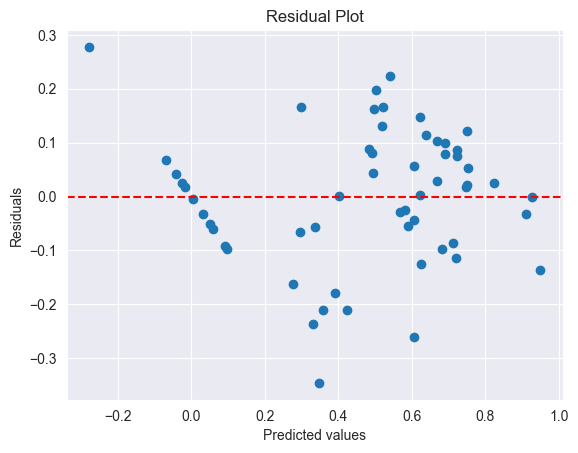

train: Sort by y_true and delta
train: Sort by y_true and |delta|
val: Sort by y_true and delta
val: Sort by y_true and |delta|


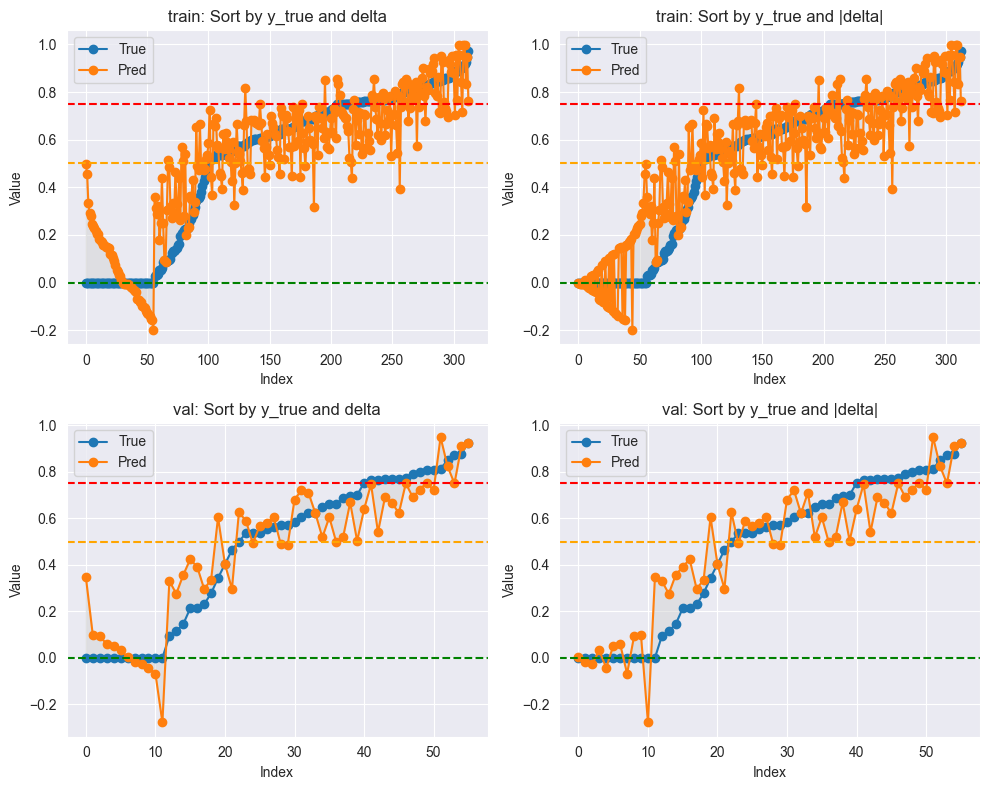

In [135]:
import matplotlib.pyplot as plt

report.section()
y_true = compound_preds[TARGET_COLUMN]
y_pred = compound_preds["prediction"]

train_df = pd.DataFrame()
train_df["y_true_train"] = y_train
train_df["y_pred_train"] = model.predict(X_train)
y_true_train = train_df["y_true_train"]
y_pred_train = train_df["y_pred_train"]

delta = y_true - y_pred
delta_train = y_true_train - y_pred_train

residuals = delta
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red', linestyle='--')  # zero line
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show("Residual plot")

sort_by_y_true = np.lexsort((delta, y_true))
sort_by_y_true_train = np.lexsort((delta_train, y_true_train))

sort_by_y_true_delta = np.lexsort((np.abs(delta), y_true))
sort_by_y_true_delta_train = np.lexsort((np.abs(delta_train), y_true_train))

sortings = {
    # 'Sort by delta': sort_by_delta,
    # 'Sort by |delta|': sort_by_abs_delta,
    'train: Sort by y_true and delta': (sort_by_y_true_train, y_true_train, y_pred_train),
    'train: Sort by y_true and |delta|': (sort_by_y_true_delta_train, y_true_train, y_pred_train),
    'val: Sort by y_true and delta': (sort_by_y_true, y_true, y_pred),
    'val: Sort by y_true and |delta|': (sort_by_y_true_delta, y_true, y_pred),
}

fig, axs = plt.subplots(2, 2, figsize=(10, 8))

for ax, (title, content) in zip(axs.flat, sortings.items()):
    print(title)
    indices, _y_true, _y_pred = content
    y_true_sorted = _y_true.iloc[indices].reset_index(drop=True)
    y_pred_sorted = _y_pred.iloc[indices].reset_index(drop=True)

    ax.plot(y_true_sorted, label='True', marker='o')
    ax.plot(y_pred_sorted, label='Pred', marker='o')
    ax.fill_between(range(len(y_true_sorted)), y_true_sorted, y_pred_sorted, color='lightgray', alpha=0.5)
    ax.axhline(0, color='green', linestyle='--')
    ax.axhline(0.5, color='orange', linestyle='--')
    ax.axhline(0.75, color='red', linestyle='--')
    ax.set_title(title)
    ax.set_xlabel('Index')
    ax.set_ylabel('Value')
    ax.legend()

plt.tight_layout()
plt.show("pred_true_plot")

In [136]:
X_train
y_train

551    0.000000
806    0.000000
709    0.802885
175    0.000000
826    0.708333
         ...   
440    0.089905
865    0.031468
569    0.764085
308    0.765060
238    0.059344
Name: label1, Length: 313, dtype: float64

In [137]:
import plotly.express as px

train_preds = model.predict(X_train)

compound_train_preds = base_y_train.copy(deep=True)
print(compound_train_preds.shape)
compound_train_preds["prediction"] = train_preds

fig = px.scatter(
    compound_train_preds,
    x=TARGET_COLUMN,
    y=compound_train_preds.index,
    color=TARGET_COLUMN,
    color_continuous_scale=["blue", "red"],  # for binary
    hover_data=["ID", "grade", "speed", "label1", "task"],
    title="train_true_distribution"
)
fig.add_vline(x=0.0 if SCALE_TYPE == "lower_is_better" else 1.0, line_dash="dash", line_color="green")
fig.add_vline(x=0.5 if SCALE_TYPE == "lower_is_better" else 0.75, line_dash="dash", line_color="orange")
fig.add_vline(x=0.75 if SCALE_TYPE == "lower_is_better" else 0.0, line_dash="dash", line_color="red")
fig.show("train_true_distribution")

fig = px.scatter(
    compound_train_preds,
    x="prediction",
    y=compound_train_preds.index,
    color="prediction",
    color_continuous_scale=["blue", "red"],  # for binary
    hover_data=["ID", "grade", "speed", "label1", "task"],
    title="train_pred_distribution"
)
fig.add_vline(x=0.0 if SCALE_TYPE == "lower_is_better" else 1.0, line_dash="dash", line_color="green")
fig.add_vline(x=0.5 if SCALE_TYPE == "lower_is_better" else 0.75, line_dash="dash", line_color="orange")
fig.add_vline(x=0.75 if SCALE_TYPE == "lower_is_better" else 0.0, line_dash="dash", line_color="red")
fig.show("train_pred_distribution")

(313, 7)


train distribution

In [138]:

fig = px.scatter(
    compound_preds,
    x=TARGET_COLUMN,
    y=compound_preds.index,
    color=TARGET_COLUMN,
    color_continuous_scale=["blue", "red"],  # for binary
    hover_data=["ID", "grade", "speed", "label1", "orig_label1", "task"],
    title="test_true_distribution"
)
fig.add_vline(x=0.0 if SCALE_TYPE == "lower_is_better" else 1.0, line_dash="dash", line_color="green")
fig.add_vline(x=0.5 if SCALE_TYPE == "lower_is_better" else 0.75, line_dash="dash", line_color="orange")
fig.add_vline(x=0.75 if SCALE_TYPE == "lower_is_better" else 0.0, line_dash="dash", line_color="red")
fig.show("test_true_distribution")

fig = px.scatter(
    compound_preds,
    x="prediction",
    y=compound_preds.index,
    color=TARGET_COLUMN,
    color_continuous_scale=["blue", "red"],  # for binary
    hover_data=["ID", "grade", "speed", "label1", "orig_label1", "task"],
    title="test_pred_distribution"
)
fig.add_vline(x=0.0 if SCALE_TYPE == "lower_is_better" else 1.0, line_dash="dash", line_color="green")
fig.add_vline(x=0.5 if SCALE_TYPE == "lower_is_better" else 0.75, line_dash="dash", line_color="orange")
fig.add_vline(x=0.75 if SCALE_TYPE == "lower_is_better" else 0.0, line_dash="dash", line_color="red")
fig.show("test_pred_distribution")

In [139]:
compound_preds

,ID,grade,gender,task,speed,label1,orig_label1,prediction,error,error_abs,error%
199,m8,1.00,1.0,lobster,64.0,0.807229,1.0,0.721461,0.085768,0.085768,0.106250
915,mat19,0.75,0.0,zoo,119.0,0.000000,0.0,-0.067751,0.067751,0.067751,inf
509,kar72,0.50,1.0,trick,67.0,0.114655,0.0,0.276174,-0.161518,0.161518,1.408727
1300,ds10,0.25,1.0,zoo,12.0,0.769231,1.0,0.622408,0.146823,0.146823,0.190870
761,nnz55,0.25,1.0,trick,104.0,0.000000,0.0,-0.277600,0.277600,0.277600,inf
872,kar14,1.00,0.0,zoo,69.0,0.696428,0.5,0.668221,0.028206,0.028206,0.040502
645,nnr14,0.75,1.0,trick,121.0,0.000000,0.0,0.005019,-0.005019,0.005019,inf
704,nnr74,0.75,1.0,trick,67.0,0.499999,0.0,0.625336,-0.125337,0.125337,0.250674
198,m7,0.50,1.0,lobster,27.0,0.850000,1.0,0.824296,0.025704,0.025704,0.030240
1192,nnr9,0.75,0.0,zoo,62.0,0.535714,0.5,0.590675,-0.054961,0.054961,0.102594


In [140]:
# raise Exception("End of execution")

In [141]:
# pseudocls

# # zoo
# zoo_grade_thresholds = {
#     1: [13, 23],
#     2: [37, 49],
#     3: [50, 64],
#     4: [66, 80]
# }
#
# # trick
# trick_grade_thresholds = {
#     1: [6, 18],
#     2: [33, 47],
#     3: [52, 67],
#     4: [71, 84]
# }
#
# # lobster
# lobster_grade_thresholds = {
#     1:[23, 30],
#     2:[45, 54],
#     3:[67, 75],
#     4:[83, 87],
# }
#
# # trick
# grade_thresholds = {
#     "zoo": zoo_grade_thresholds,
#     "trick": trick_grade_thresholds,
#     "lobster": lobster_grade_thresholds
# }





In [142]:
def clamp3(x):
    if SCALE_TYPE == "lower_is_better":
        if x < 0.45:
            return 0
        elif x < 0.70:
            return 0.5
        else:
            return 1
    elif SCALE_TYPE == "higher_is_better":
        if x < 0.55:
            return 0
        elif x < 0.80:
            return 0.5
        else:
            return 1
    raise Exception(f"Unknown scale type {SCALE_TYPE}")

def clamp2(x):
    if SCALE_TYPE == "lower_is_better":
        if x < 0.45:
            return 0
        return 1
    elif SCALE_TYPE == "higher_is_better":
        if x < 0.55:
            return 0
        return 1
    raise Exception(f"Unknown scale type {SCALE_TYPE}")

# todo: get x-separator using TRAIN data
# todo: show distribution on train data and test data

In [143]:
clamp_fn = clamp2
if THRESHOLD_SPLITS == 3:
    clamp_fn = clamp3
clamp_fn = clamp2

In [144]:
compound_preds.iloc[1]["orig_label1"]

np.float64(0.0)

In [145]:
compound_preds = base_y_val.copy(deep=True)
print(compound_preds.shape)
compound_preds["prediction"] = preds
# compound_preds

inferred_classes = []
true_classes = []

for i, row in compound_preds.iterrows():
    task = row.task
    pred = row.prediction
    grade = row.grade
    inferred_class = clamp_fn(pred)
    true_class = clamp_fn(row.orig_label1)
    inferred_classes.append(inferred_class)
    true_classes.append(true_class)

compound_preds["inferred_class"] = inferred_classes
compound_preds["true_class"] = true_classes
compound_preds["error"] = compound_preds["prediction"] - compound_preds["true_class"]
compound_preds["error_abs"] = compound_preds["error"].abs()

cols = list(compound_preds.columns)  # get all columns
col = cols.pop(1)  # remove column at index 2
cols.append(col)  # add it to the end
compound_preds = compound_preds[cols]

compound_preds



(56, 7)


,ID,gender,task,speed,label1,orig_label1,prediction,inferred_class,true_class,error,error_abs,grade
199,m8,1.0,lobster,64.0,0.807229,1.0,0.721461,1,1,-0.278539,0.278539,1.00
915,mat19,0.0,zoo,119.0,0.000000,0.0,-0.067751,0,0,-0.067751,0.067751,0.75
509,kar72,1.0,trick,67.0,0.114655,0.0,0.276174,0,0,0.276174,0.276174,0.50
1300,ds10,1.0,zoo,12.0,0.769231,1.0,0.622408,1,1,-0.377592,0.377592,0.25
761,nnz55,1.0,trick,104.0,0.000000,0.0,-0.277600,0,0,-0.277600,0.277600,0.25
872,kar14,0.0,zoo,69.0,0.696428,0.5,0.668221,1,1,-0.331779,0.331779,1.00
645,nnr14,1.0,trick,121.0,0.000000,0.0,0.005019,0,0,0.005019,0.005019,0.75
704,nnr74,1.0,trick,67.0,0.499999,0.0,0.625336,1,0,0.625336,0.625336,0.75
198,m7,1.0,lobster,27.0,0.850000,1.0,0.824296,1,1,-0.175704,0.175704,0.50
1192,nnr9,0.0,zoo,62.0,0.535714,0.5,0.590675,1,1,-0.409325,0.409325,0.75


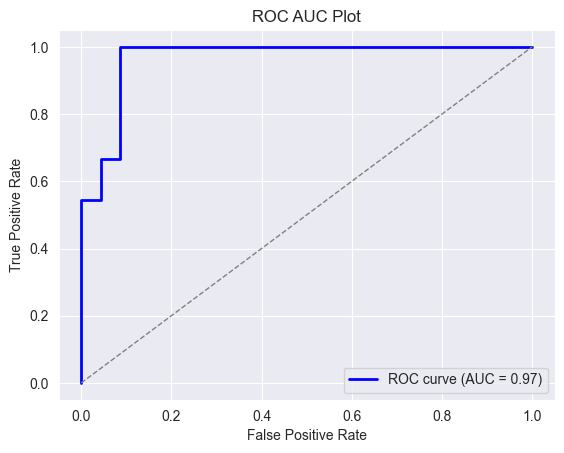

In [146]:
from sklearn.metrics import roc_curve, auc

try:
    fpr, tpr, thresholds = roc_curve(compound_preds["true_class"], compound_preds["prediction"])
    roc_auc = auc(fpr, tpr)

    # Plot
    plt.figure()
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC AUC Plot')
    plt.legend(loc="lower right")
    plt.show("roc_auc")
except:
    print("Unable to get rocauc (more than 2 classes?)")

## Overall


## Overall


Overall/0/precision: 1.0
Overall/0/recall: 0.9130434782608695
Overall/0/f1-score: 0.9545454545454546
Overall/0/support: 23.0
Overall/10/precision: 0.9428571428571428
Overall/10/recall: 1.0
Overall/10/f1-score: 0.9705882352941176
Overall/10/support: 33.0
Overall/accuracy: 0.9642857142857143
Overall/macro avg/precision: 0.9714285714285714
Overall/macro avg/recall: 0.9565217391304348
Overall/macro avg/f1-score: 0.9625668449197862
Overall/macro avg/support: 56.0
Overall/weighted avg/precision: 0.9663265306122449
Overall/weighted avg/recall: 0.9642857142857143
Overall/weighted avg/f1-score: 0.9639992360580596
Overall/weighted avg/support: 56.0


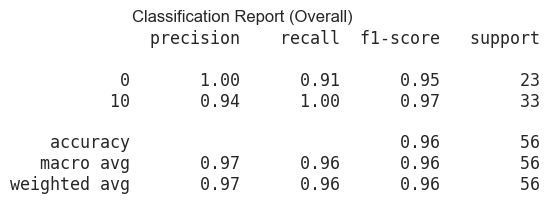

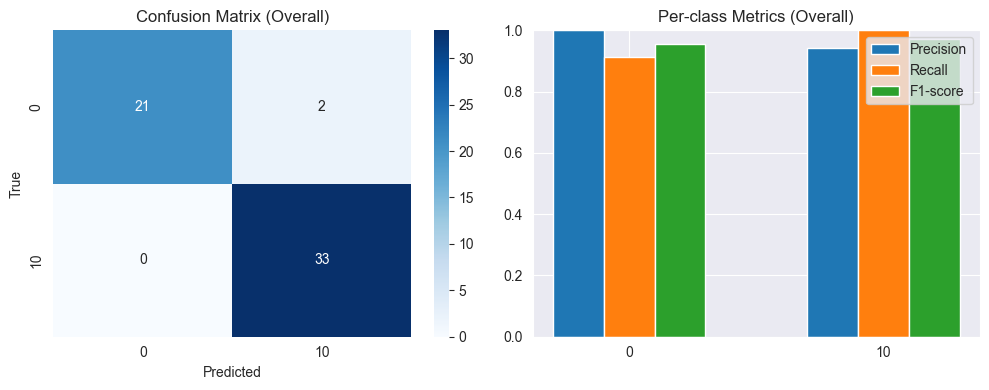


## 1 grade


## 1 grade


1 grade/0/precision: 1.0
1 grade/0/recall: 0.8333333333333334
1 grade/0/f1-score: 0.9090909090909091
1 grade/0/support: 6.0
1 grade/10/precision: 0.8571428571428571
1 grade/10/recall: 1.0
1 grade/10/f1-score: 0.9230769230769231
1 grade/10/support: 6.0
1 grade/accuracy: 0.9166666666666666
1 grade/macro avg/precision: 0.9285714285714286
1 grade/macro avg/recall: 0.9166666666666667
1 grade/macro avg/f1-score: 0.916083916083916
1 grade/macro avg/support: 12.0
1 grade/weighted avg/precision: 0.9285714285714285
1 grade/weighted avg/recall: 0.9166666666666666
1 grade/weighted avg/f1-score: 0.9160839160839161
1 grade/weighted avg/support: 12.0


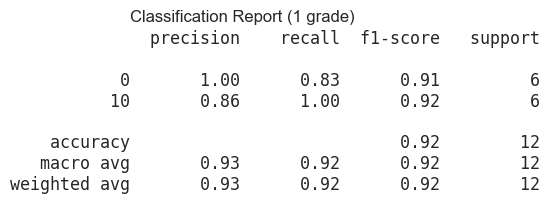

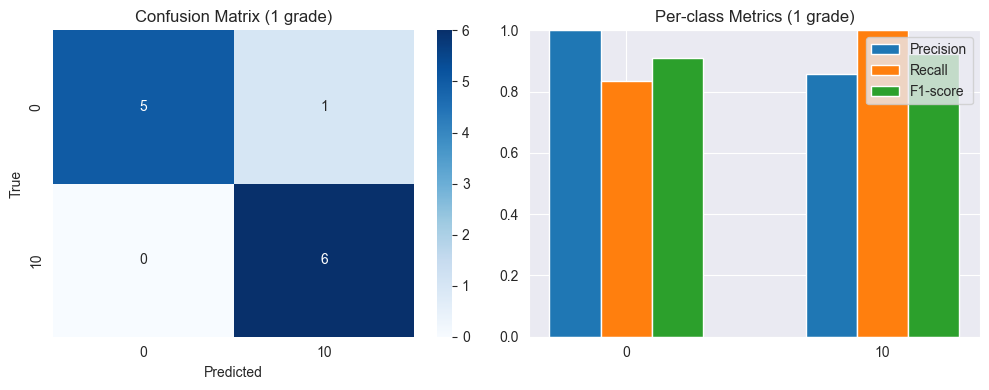

## 2 grade


## 2 grade


2 grade/0/precision: 1.0
2 grade/0/recall: 1.0
2 grade/0/f1-score: 1.0
2 grade/0/support: 5.0
2 grade/10/precision: 1.0
2 grade/10/recall: 1.0
2 grade/10/f1-score: 1.0
2 grade/10/support: 11.0
2 grade/accuracy: 1.0
2 grade/macro avg/precision: 1.0
2 grade/macro avg/recall: 1.0
2 grade/macro avg/f1-score: 1.0
2 grade/macro avg/support: 16.0
2 grade/weighted avg/precision: 1.0
2 grade/weighted avg/recall: 1.0
2 grade/weighted avg/f1-score: 1.0
2 grade/weighted avg/support: 16.0


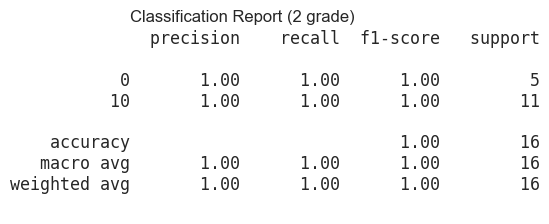

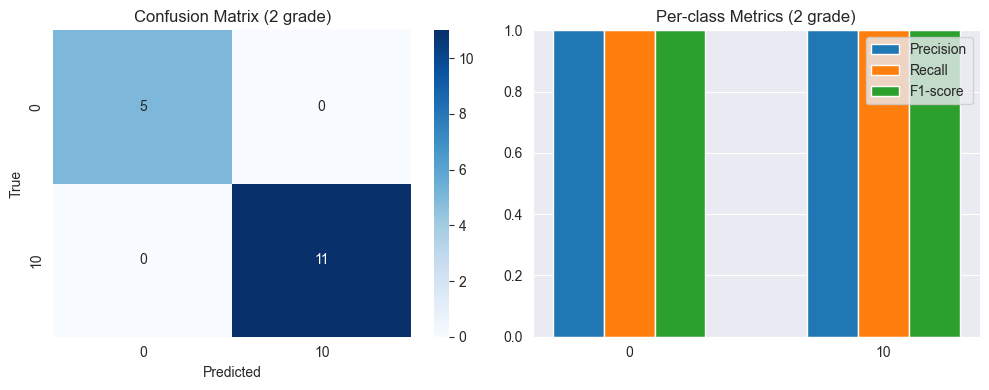

## 3 grade


## 3 grade


3 grade/0/precision: 1.0
3 grade/0/recall: 0.9
3 grade/0/f1-score: 0.9473684210526315
3 grade/0/support: 10.0
3 grade/10/precision: 0.9090909090909091
3 grade/10/recall: 1.0
3 grade/10/f1-score: 0.9523809523809523
3 grade/10/support: 10.0
3 grade/accuracy: 0.95
3 grade/macro avg/precision: 0.9545454545454546
3 grade/macro avg/recall: 0.95
3 grade/macro avg/f1-score: 0.949874686716792
3 grade/macro avg/support: 20.0
3 grade/weighted avg/precision: 0.9545454545454545
3 grade/weighted avg/recall: 0.95
3 grade/weighted avg/f1-score: 0.949874686716792
3 grade/weighted avg/support: 20.0


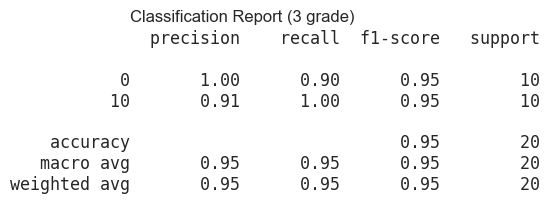

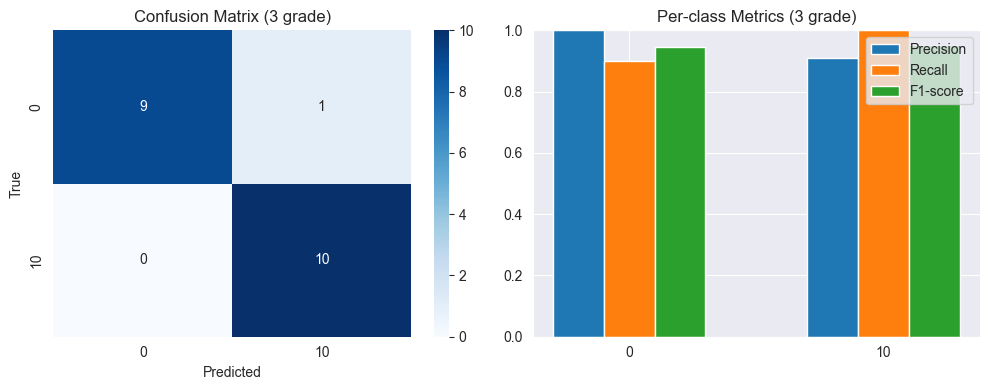

## 4 grade


## 4 grade


4 grade/0/precision: 1.0
4 grade/0/recall: 1.0
4 grade/0/f1-score: 1.0
4 grade/0/support: 2.0
4 grade/10/precision: 1.0
4 grade/10/recall: 1.0
4 grade/10/f1-score: 1.0
4 grade/10/support: 6.0
4 grade/accuracy: 1.0
4 grade/macro avg/precision: 1.0
4 grade/macro avg/recall: 1.0
4 grade/macro avg/f1-score: 1.0
4 grade/macro avg/support: 8.0
4 grade/weighted avg/precision: 1.0
4 grade/weighted avg/recall: 1.0
4 grade/weighted avg/f1-score: 1.0
4 grade/weighted avg/support: 8.0


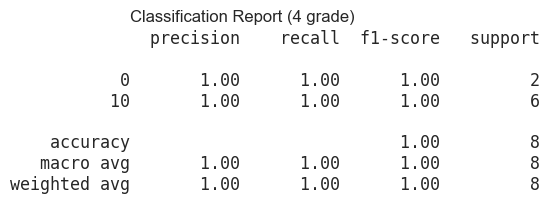

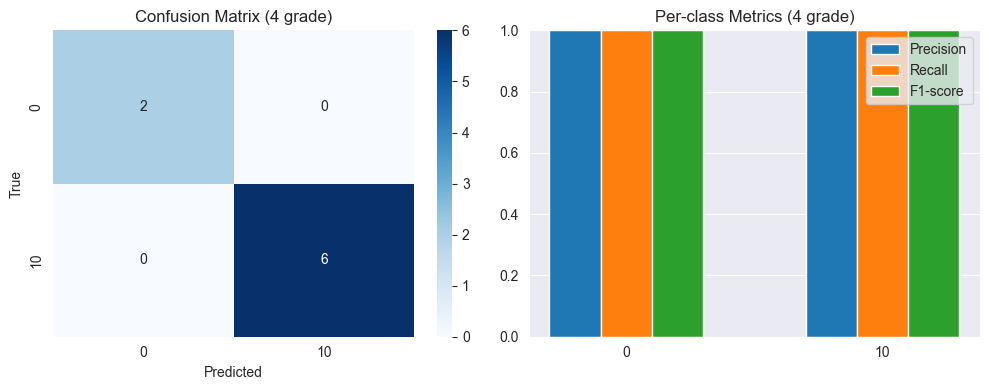


## Only male


## Only male


Only male/0/precision: 1.0
Only male/0/recall: 0.8181818181818182
Only male/0/f1-score: 0.9
Only male/0/support: 11.0
Only male/10/precision: 0.9
Only male/10/recall: 1.0
Only male/10/f1-score: 0.9473684210526315
Only male/10/support: 18.0
Only male/accuracy: 0.9310344827586207
Only male/macro avg/precision: 0.95
Only male/macro avg/recall: 0.9090909090909092
Only male/macro avg/f1-score: 0.9236842105263158
Only male/macro avg/support: 29.0
Only male/weighted avg/precision: 0.9379310344827586
Only male/weighted avg/recall: 0.9310344827586207
Only male/weighted avg/f1-score: 0.9294010889292196
Only male/weighted avg/support: 29.0


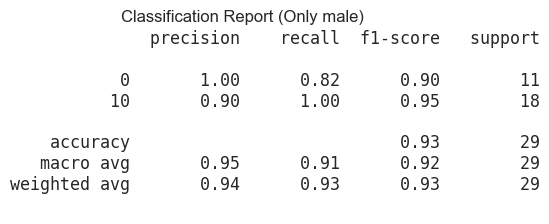

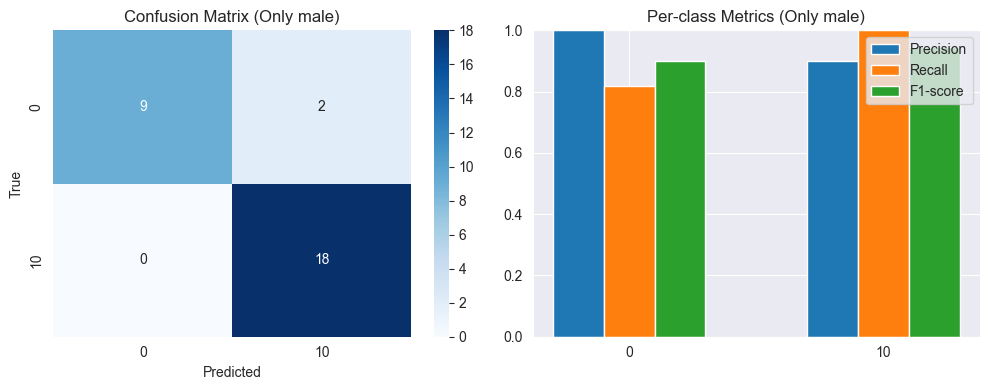

## Only female


## Only female


Only female/0/precision: 1.0
Only female/0/recall: 1.0
Only female/0/f1-score: 1.0
Only female/0/support: 12.0
Only female/10/precision: 1.0
Only female/10/recall: 1.0
Only female/10/f1-score: 1.0
Only female/10/support: 15.0
Only female/accuracy: 1.0
Only female/macro avg/precision: 1.0
Only female/macro avg/recall: 1.0
Only female/macro avg/f1-score: 1.0
Only female/macro avg/support: 27.0
Only female/weighted avg/precision: 1.0
Only female/weighted avg/recall: 1.0
Only female/weighted avg/f1-score: 1.0
Only female/weighted avg/support: 27.0


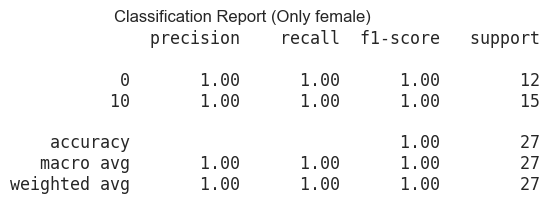

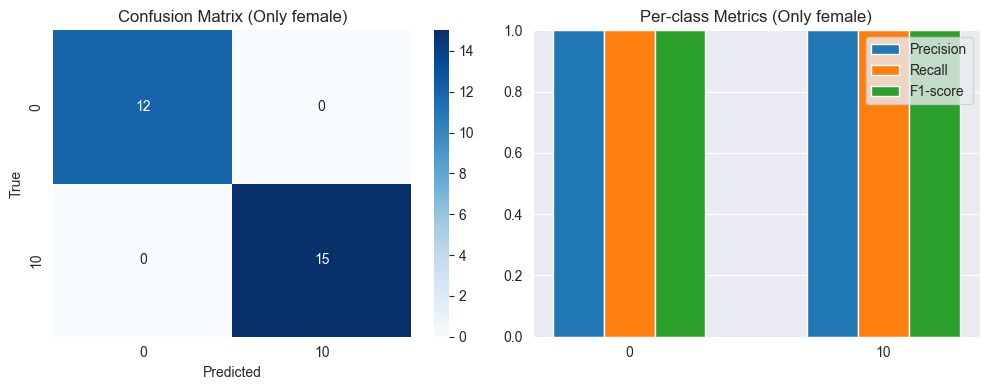


## Task zoo


## Task zoo


Task zoo/0/precision: 1.0
Task zoo/0/recall: 1.0
Task zoo/0/f1-score: 1.0
Task zoo/0/support: 6.0
Task zoo/10/precision: 1.0
Task zoo/10/recall: 1.0
Task zoo/10/f1-score: 1.0
Task zoo/10/support: 16.0
Task zoo/accuracy: 1.0
Task zoo/macro avg/precision: 1.0
Task zoo/macro avg/recall: 1.0
Task zoo/macro avg/f1-score: 1.0
Task zoo/macro avg/support: 22.0
Task zoo/weighted avg/precision: 1.0
Task zoo/weighted avg/recall: 1.0
Task zoo/weighted avg/f1-score: 1.0
Task zoo/weighted avg/support: 22.0


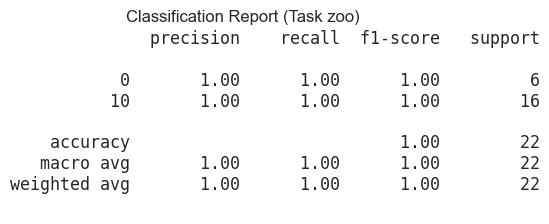

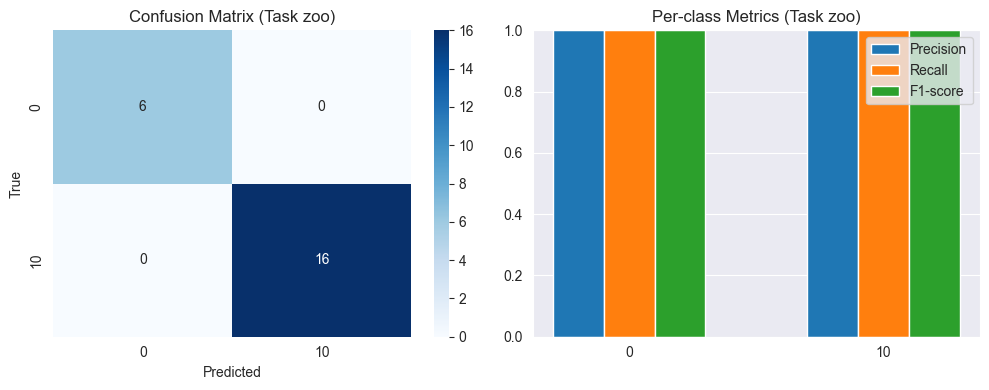

## Task trick


## Task trick


Task trick/0/precision: 1.0
Task trick/0/recall: 0.8666666666666667
Task trick/0/f1-score: 0.9285714285714286
Task trick/0/support: 15.0
Task trick/10/precision: 0.7777777777777778
Task trick/10/recall: 1.0
Task trick/10/f1-score: 0.875
Task trick/10/support: 7.0
Task trick/accuracy: 0.9090909090909091
Task trick/macro avg/precision: 0.8888888888888888
Task trick/macro avg/recall: 0.9333333333333333
Task trick/macro avg/f1-score: 0.9017857142857143
Task trick/macro avg/support: 22.0
Task trick/weighted avg/precision: 0.9292929292929292
Task trick/weighted avg/recall: 0.9090909090909091
Task trick/weighted avg/f1-score: 0.9115259740259741
Task trick/weighted avg/support: 22.0


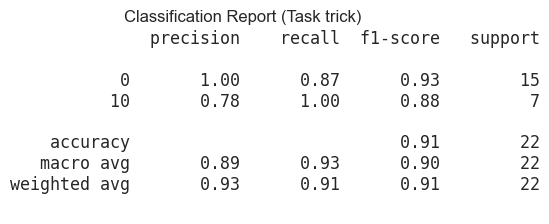

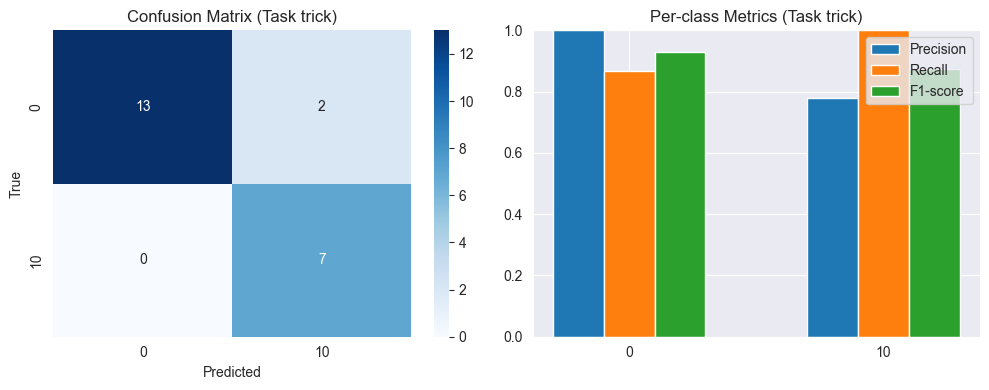

## Task lobster


## Task lobster


Task lobster/0/precision: 1.0
Task lobster/0/recall: 1.0
Task lobster/0/f1-score: 1.0
Task lobster/0/support: 2.0
Task lobster/10/precision: 1.0
Task lobster/10/recall: 1.0
Task lobster/10/f1-score: 1.0
Task lobster/10/support: 10.0
Task lobster/accuracy: 1.0
Task lobster/macro avg/precision: 1.0
Task lobster/macro avg/recall: 1.0
Task lobster/macro avg/f1-score: 1.0
Task lobster/macro avg/support: 12.0
Task lobster/weighted avg/precision: 1.0
Task lobster/weighted avg/recall: 1.0
Task lobster/weighted avg/f1-score: 1.0
Task lobster/weighted avg/support: 12.0


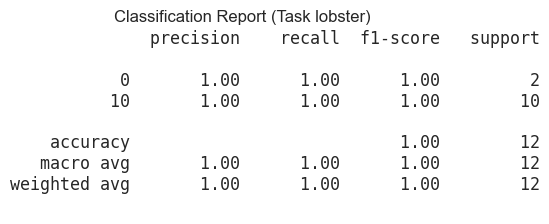

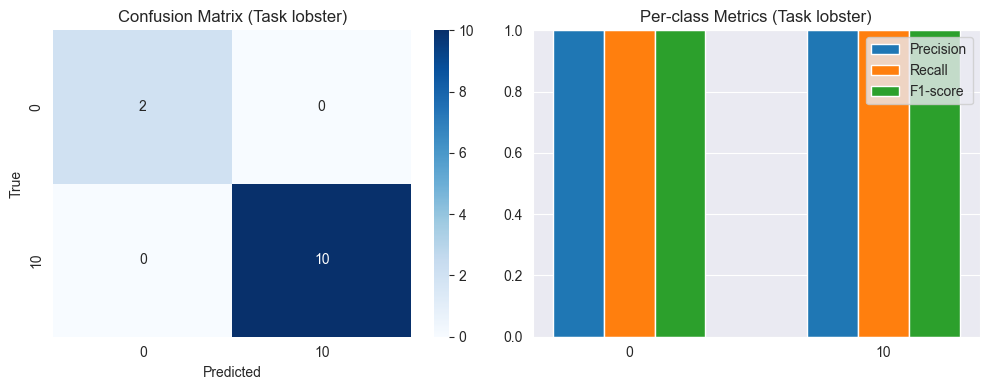

In [147]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns


def unwrap(key_start, dict_):
    result = {}
    try:
        for k, v in dict_.items():
            unwrapped = unwrap(f"{key_start}/{k}", v)
            result.update(unwrapped)
    except:
        return {key_start: dict_}
    return result


def make_metrics(df, title="Unnamed"):
    if df is None:
        print("=" * 80)
        print()
        return

    y_true = df["true_class"] * 10
    y_pred = df["inferred_class"] * 10

    if len(y_true) != len(y_pred) or len(y_true) == 0:
        print(f"No metrics for {title} - test set is empty")
        return

    report.section(title, ReportTarget.footer)
    report.section(title, ReportTarget.body)

    classes = list(sorted(set(y_true)))

    cls_report = classification_report(y_true, y_pred, output_dict=True)
    flat_report = unwrap(title, cls_report)
    for k, v in flat_report.items():
        report(k, v, ReportTarget.footer)

    cls_report_str = classification_report(y_true, y_pred)
    plt.figure(figsize=(6, 2))
    plt.text(0, 1, cls_report_str, fontfamily='monospace', fontsize=12, va='top')  # va='top' aligns top
    plt.axis('off')  # hide axes
    plt.title(f"Classification Report ({title})")
    plt.show(f"classification_report_{title}")
    cm = None
    try:
        cm = confusion_matrix(y_true, y_pred)
    except:
        print("Unable to make CM")
    # print(cm)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    x = np.arange(len(classes))

    if cm is not None:
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes, ax=axes[0])
        axes[0].set_xlabel("Predicted")
        axes[0].set_ylabel("True")
        axes[0].set_title(f"Confusion Matrix ({title})")

    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, labels=classes)
    axes[1].bar(x - 0.2, precision, width=0.2, label="Precision")
    axes[1].bar(x, recall, width=0.2, label="Recall")
    axes[1].bar(x + 0.2, f1, width=0.2, label="F1-score")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(classes)
    axes[1].set_ylim(0, 1)
    axes[1].legend()
    axes[1].set_title(f"Per-class Metrics ({title})")

    plt.tight_layout()
    plt.show(f"per-class_metrics_{title}")

    print("=" * 80)


metrics_df_config = {
    "Overall": compound_preds,
    "delimiter1": None,
    **{f"{i + 1} grade": compound_preds[compound_preds["grade"] == elem] for i, elem in
       enumerate(sorted(compound_preds["grade"].unique()))},
    "delimiter2": None,
    "Only male": compound_preds[compound_preds["gender"] == 1],
    "Only female": compound_preds[compound_preds["gender"] == 0],
    "delimiter3": None,
    "Task zoo": compound_preds[compound_preds["task"] == "zoo"],
    "Task trick": compound_preds[compound_preds["task"] == "trick"],
    "Task lobster": compound_preds[compound_preds["task"] == "lobster"],
}

for k, v in metrics_df_config.items():
    make_metrics(v, title=k)


In [148]:
report.save()

pdf saved
